# Options européennes sur OAT sous un modèle gaussien à deux facteurs

> **Alexis Dantzikian** — mémoire de recherche, septembre 2026

## Objectif

Ce notebook construit, calibre et valide un pricer d'**options européennes sur obligations d'État
françaises (OAT)** dans le **modèle gaussien à deux facteurs corrélés** de Russo, Giacometti et Fabozzi
(*Closed-Form Solution for Defaultable Bond Options under a Two-Factor Gaussian Model for Risky Rates
Modeling*, draft). Le premier facteur est le taux sans risque (Hull-White à un facteur sur la courbe €STR),
le second est le spread de crédit souverain (Hull-White à un facteur sur le spread court). Le modèle
recale exactement la courbe OAT observée et les deux facteurs sont corrélés.

Le papier de Russo et al. traite d'obligations *corporate* américaines par notation et suppose que l'option
est **knock-out au défaut** (valeur nulle pour le porteur si l'émetteur fait défaut avant l'échéance). On
s'écarte du papier sur ce seul point : ici **le défaut n'est pas pris en compte dans l'option**. L'option est
un contrat collatéralisé dont la contrepartie n'est pas l'émetteur de l'obligation ; elle paie à l'échéance
$T_0$ la différence positive entre le prix de marché de l'OAT et le strike, et elle est actualisée au taux
sans risque :

$$C(t) = \mathbb E^{\mathbb Q}\Big[e^{-\int_t^{T_0} r(u)\,du}\,\big(\bar B(T_0) - X\big)^+\,\Big|\,\mathcal F_t\Big].$$

Ce changement de contrat change la mesure de pricing et la formule fermée (section 8) : le forward du prix
risqué n'est plus une martingale sous la mesure forward sans risque, et son espérance doit être calculée
explicitement. Le reste du cadre (dynamiques, recalage des courbes, durations stochastiques, hypothèse
lognormale approchée, procédure de calibration en deux étapes) est celui de Russo et al.

Une simplification de notation : Russo écrit le spread court $s = L\lambda$ avec $\lambda$ l'intensité de
défaut et $L$ la perte en cas de défaut. Comme la courbe OAT est recalée directement et que seule la
volatilité du spread $L\sigma_\lambda$ entre dans les prix, $L$ n'est pas un paramètre du pricer (avec ou sans
knock-out). On modélise donc **directement le spread** : le second facteur est le facteur de spread et
$\sigma_y$ est une volatilité de spread. La section 7 précise le lien avec l'écriture de Russo.

## Plan

| Section | Contenu | Contrôle numérique |
|---|---|---|
| 1 | Données de marché Bloomberg au 08/09/2026 | unités, dates, cohérence des historiques |
| 2 | Courbe sans risque €STR | re-pricing des swaps, forward instantané |
| 3 | Courbe OAT (Nelson-Siegel-Svensson) | re-pricing des OAT, coupon couru |
| 4 | Briques gaussiennes | limites, quadratures |
| 5 | Hull-White 1 facteur, options sur obligation, swaptions | recalage, parité, Jamshidian |
| 6 | Calibration étape 1 : $(a_x,\sigma_x)$ sur swaptions | résidus, stabilité |
| 7 | Modèle à deux facteurs | recalage, dérivées, limite $L \to 0$ |
| 8 | Option sur OAT sans knock-out : formule fermée | parité, cas limites |
| 9 | Calibration étape 2 : $(a_y,\sigma_y,\rho)$ | réplication de Russo, calibration historique |
| 10 | Monte-Carlo exact | fermé vs simulé, intervalles de confiance |
| 11 | Résultats et sensibilités | — |
| 12 | Conclusion et limites | — |

Chaque section suit le même schéma : la théorie en markdown, une cellule « bibliothèque » (fonctions ou
petite classe) et une cellule d'exécution qui imprime les vérifications. Le code est volontairement
simple : NumPy, SciPy, pandas et matplotlib uniquement, une méthode par formule, paramètres explicites.

## Notations

| Symbole | Signification |
|---|---|
| $r(t) = \alpha(t) + x(t)$ | taux court sans risque, $x$ facteur OU de paramètres $(a_x,\sigma_x)$ |
| $s(t) = \beta(t) + y(t)$ | spread court OAT–€STR, $y$ facteur OU de paramètres $(a_y,\sigma_y)$ |
| $\bar r = r + s = \bar\alpha + x + y$ | taux court risqué, $\bar\alpha = \alpha + \beta$ |
| $\rho$ | corrélation des browniens $dW_x\,dW_y = \rho\,dt$ |
| $P(t,T)$, $\bar P(t,T)$ | zéro-coupon sans risque, zéro-coupon risqué (OAT) |
| $P^M$, $f^M$, $\bar P^M$, $\bar f^M$ | courbes de marché (prix et forward instantané) |
| $\bar B(t)$ | prix (dirty) de l'OAT à coupons, $\sum_i K_i \bar P(t,T_i)$ |
| $H_a(t,T) = \frac{1-e^{-a(T-t)}}{a}$ | duration stochastique d'un zéro-coupon |

**Conventions.** L'origine des temps $t=0$ est la date de règlement 10/09/2026 (spot des swaps €STR et
règlement des OAT cotées le 08/09/2026). Le temps est mesuré en années sur une base ACT/365 à partir de
cette date ; il n'y a pas de calendrier de jours ouvrés. Les swaps €STR ont une jambe fixe annuelle. Les
OAT paient un coupon annuel. Les prix d'options sont exprimés en pourcentage du nominal.

## 1. Données de marché

Toutes les données proviennent de Bloomberg à la clôture du **8 septembre 2026** (règlement 10/09/2026) et
sont rangées dans un classeur unique, `data/market data bloom.xlsx` :

| Onglet | Contenu | Usage |
|---|---|---|
| `ESTR CURVE` | 32 taux swap OIS €STR, 1W → 50Y, en % | courbe sans risque $P^M$, $f^M$ |
| `Swaption cube` | vols normales (Bachelier) ATM des swaptions EUR, 21 expiries × 14 tenors, en bp | calibration étape 1 |
| `Liste OAT` | 19 titres d'État français (5 zéro-coupons courts, 14 OAT 2028 → 2072) : coupon, maturité, prix pied de coupon, coupon couru, rendement | courbe OAT $\bar P^M$, sous-jacent des options |
| `Zield Histo OAT` | rendements OAT génériques 2, 5, 10, 15, 20, 25, 30 ans, quotidiens 01/2021 → 09/2026 | calibration étape 2 |
| `Yield Histo ESTR` | taux swap €STR aux mêmes tenors, quotidiens | calibration étape 2 |

Deux points de vigilance sur les historiques exportés par formule BQL : la colonne de dates mélange des
dates Excel et du texte au format américain, et Excel a interprété les jours $\le 12$ en inversant jour et
mois. La grille étant quotidienne et complète, on **reconstruit** les dates et on **vérifie** la
reconstruction sur toutes les lignes textuelles. Les valeurs sont elles aussi mélangées (texte / nombre)
et sont converties en nombres. Les week-ends et jours fériés sont vides.

In [1]:
"""
Chargement des données de marché

"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 160)
FICHIER = next(p for p in [Path("../data/market data bloom.xlsx"), Path("data/market data bloom.xlsx")] if p.exists())
DATE_VAL = pd.Timestamp("2026-09-10")      # date de règlement = origine des temps (t = 0)

def tenor_years(s):
    """'1W' -> 1/52, '18M' / '1Mo' -> 1.5 / 1/12, '10Y' / '10Yr' -> 10."""
    n = float("".join(c for c in s if c.isdigit()))
    return n / 52 if "W" in s else n / 12 if "M" in s else n

def load_estr():
    d = pd.read_excel(FICHIER, sheet_name="ESTR CURVE", usecols=["Tenor", "Yield"])
    return pd.DataFrame({"tenor": d["Tenor"], "T": d["Tenor"].map(tenor_years), "swap": d["Yield"] / 100})

def load_cube():
    v = pd.read_excel(FICHIER, sheet_name="Swaption cube", index_col=0)
    v.index = [tenor_years(s) for s in v.index]          # expiries en années
    v.columns = [tenor_years(s) for s in v.columns]      # tenors en années
    return v.astype(float) / 1e4                         # bp -> décimal

def load_oat():
    d = pd.read_excel(FICHIER, sheet_name="Liste OAT")
    d.columns = ["bbg", "isin", "coupon", "maturity", "issue", "settle", "clean", "accrued_bbg", "dirty_bbg", "ytm_bbg"]
    for c in ["coupon", "clean", "accrued_bbg", "dirty_bbg", "ytm_bbg"]:
        d[c] = pd.to_numeric(d[c])
    for c in ["maturity", "issue", "settle"]:
        d[c] = pd.to_datetime(d[c])
    d["coupon"] /= 100
    d["ytm_bbg"] /= 100
    return d

def load_history(sheet):
    raw = pd.read_excel(FICHIER, sheet_name=sheet, header=None)
    tickers = raw.iloc[0, 1:].tolist()
    body = raw.iloc[2:].reset_index(drop=True)
    dates = pd.date_range("2021-01-01", periods=len(body), freq="D")      # grille quotidienne reconstruite
    is_txt = body[0].map(lambda v: isinstance(v, str)).values
    check = pd.to_datetime(body.loc[is_txt, 0], format="%m/%d/%Y")
    assert (check.values == dates[is_txt].values).all(), "grille de dates incohérente"
    h = body.iloc[:, 1:].apply(pd.to_numeric, errors="coerce") / 100
    h.index = dates
    h.columns = [int("".join(c for c in t.split()[0] if c.isdigit())) for t in tickers]   # tenor en années
    return h.sort_index(axis=1).dropna(how="all")

estr = load_estr()
cube = load_cube()
oat = load_oat()
hist_oat, hist_estr = load_history("Zield Histo OAT"), load_history("Yield Histo ESTR")

print("Courbe €STR :", len(estr), "piliers de", estr["T"].min().round(3), "à", estr["T"].max(), "ans")
print(estr.set_index("tenor")["swap"].map("{:.4%}".format).to_frame().T.to_string(), "\n")
print("Cube de vols ATM :", cube.shape, "(expiries x tenors), en bp :")
print((cube * 1e4).round(1).to_string(), "\n")
print("OAT :", len(oat), "titres")
print(oat[["isin", "coupon", "maturity", "clean", "accrued_bbg", "dirty_bbg", "ytm_bbg"]].to_string(index=False), "\n")
for nom, h in [("OAT", hist_oat), ("€STR", hist_estr)]:
    print(f"Historique {nom} : {h.index[0].date()} -> {h.index[-1].date()}, {len(h)} jours, tenors {list(h.columns)}, "
          f"valeurs manquantes par colonne : {h.isna().sum().to_dict()}")

Courbe €STR : 32 piliers de 0.019 à 50.0 ans
tenor       1W       2W       1M       2M       3M       4M       5M       6M       7M       8M       9M      10M      11M       1Y      18M       2Y       3Y       4Y       5Y       6Y       7Y       8Y       9Y      10Y      11Y      12Y      15Y      20Y      25Y      30Y      40Y      50Y
swap   2.2260%  2.3330%  2.3951%  2.4253%  2.4536%  2.4952%  2.5330%  2.5685%  2.6100%  2.6430%  2.6760%  2.7104%  2.7372%  2.7640%  2.8393%  2.8816%  2.9220%  2.9477%  2.9790%  3.0090%  3.0419%  3.0787%  3.1170%  3.1574%  3.1895%  3.2200%  3.3006%  3.3610%  3.3490%  3.3059%  3.1900%  3.0440% 

Cube de vols ATM : (21, 14) (expiries x tenors), en bp :
           1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0  15.0  20.0  25.0  30.0
0.083333   60.4  72.9  71.5  68.4  64.9  63.0  61.5  60.1  59.0  58.0  54.6  52.4  51.0  50.3
0.166667   64.0  74.1  72.5  70.2  67.8  65.9  64.4  63.0  61.7  60.7  57.3  54.7  53.1  52.1
0.250000   68.7  76.4  74.

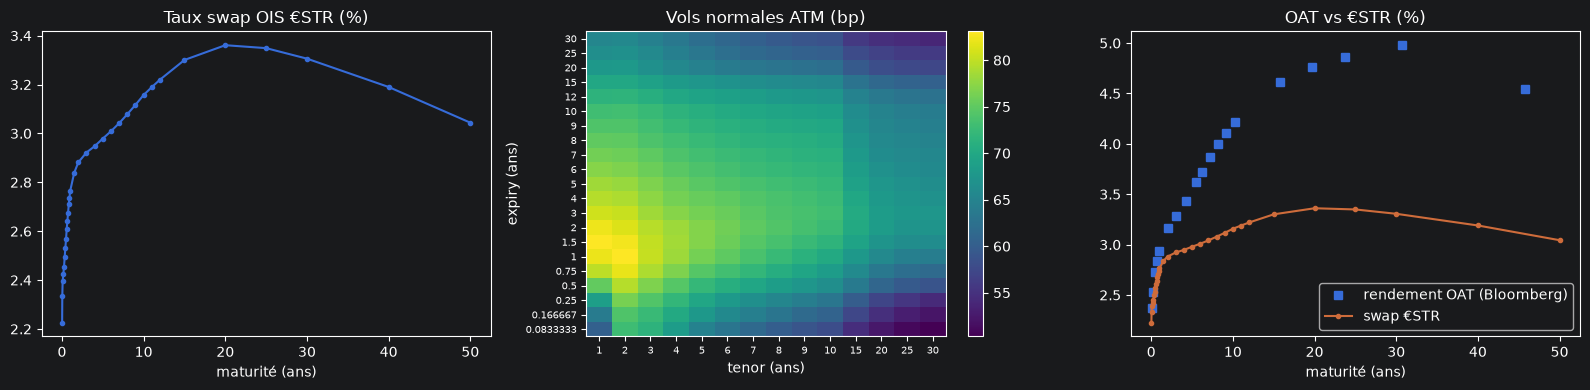

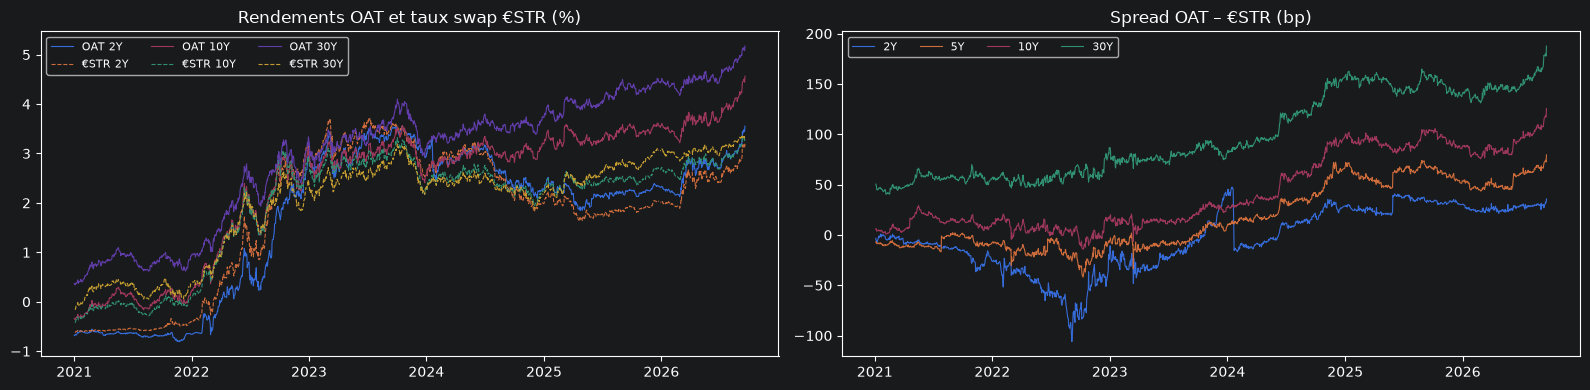

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(estr["T"], estr["swap"] * 100, "o-", ms=3); ax[0].set_title("Taux swap OIS €STR (%)"); ax[0].set_xlabel("maturité (ans)")
im = ax[1].imshow(cube * 1e4, aspect="auto", cmap="viridis", origin="lower")
ax[1].set_xticks(range(len(cube.columns))); ax[1].set_xticklabels([f"{c:g}" for c in cube.columns], fontsize=7)
ax[1].set_yticks(range(len(cube.index))); ax[1].set_yticklabels([f"{i:g}" for i in cube.index], fontsize=7)
ax[1].set_xlabel("tenor (ans)"); ax[1].set_ylabel("expiry (ans)"); ax[1].set_title("Vols normales ATM (bp)"); plt.colorbar(im, ax=ax[1])
T_oat = (oat["maturity"] - DATE_VAL).dt.days / 365
ax[2].plot(T_oat, oat["ytm_bbg"] * 100, "s", label="rendement OAT (Bloomberg)")
ax[2].plot(estr["T"], estr["swap"] * 100, ".-", label="swap €STR"); ax[2].set_xlabel("maturité (ans)"); ax[2].legend(); ax[2].set_title("OAT vs €STR (%)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
for tenor in [2, 10, 30]:
    ax[0].plot(hist_oat.index, hist_oat[tenor] * 100, lw=0.8, label=f"OAT {tenor}Y")
    ax[0].plot(hist_estr.index, hist_estr[tenor] * 100, lw=0.8, ls="--", label=f"€STR {tenor}Y")
ax[0].legend(ncol=3, fontsize=8); ax[0].set_title("Rendements OAT et taux swap €STR (%)")
spread_hist = (hist_oat - hist_estr).dropna()
for tenor in [2, 5, 10, 30]:
    ax[1].plot(spread_hist.index, spread_hist[tenor] * 1e4, lw=0.8, label=f"{tenor}Y")
ax[1].legend(ncol=4, fontsize=8); ax[1].set_title("Spread OAT – €STR (bp)")
plt.tight_layout(); plt.show()

## 2. Courbe sans risque €STR

Le taux sans risque est le taux €STR ; les swaps OIS €STR sont les instruments de calibration de la courbe
$P^M(0,T)$. Un swap de maturité $T$ et de taux fixe $S$ à jambe fixe annuelle vaut zéro à l'initiation :

$$S \sum_{i} \tau_i\,P^M(0,T_i) + P^M(0,T) = 1, \qquad T_i = T, T-1, \dots$$

(en dessous d'un an, un seul flux). On **bootstrappe** pilier par pilier : $P^M(0,T)$ est l'inconnue de
l'équation ci-dessus, les facteurs d'actualisation aux dates intermédiaires étant obtenus par interpolation
linéaire des taux zéro déjà connus.

Le modèle a besoin du **forward instantané** $f^M(0,t) = -\partial_T \log P^M(0,T)$, qui entre dans
$\alpha(t)$ et $\bar\alpha(t)$. L'interpolation doit donc produire un $\log P$ dérivable avec une dérivée
régulière. On interpole $\log P^M(0,T)$ par une **spline cubique** (nœud $\log P(0)=0$) : $f^M$ est alors
continu et $C^1$, ce qu'une interpolation linéaire des taux ne donne pas (forward en escalier). La courbe
€STR étant décroissante au-delà de 20 ans, le forward long est nettement inférieur aux taux zéro ; on le
trace pour contrôle. Le re-pricing des swaps par la courbe finale n'est pas exact au dernier chiffre : les
dates intermédiaires sont interpolées linéairement pendant le bootstrap et par la spline ensuite ; l'écart
reste inférieur au point de base.

re-pricing des 32 swaps : max |S_courbe - S_marché| = 2.5e-05
max |f^M - différences finies| = 2.8e-11
T          1        2        5        10       20       30       40       50
swap  2.7640%  2.8816%  2.9790%  3.1574%  3.3621%  3.3075%  3.1921%  3.0465%
zero  2.7265%  2.8425%  2.9397%  3.1285%  3.3560%  3.2571%  3.0639%  2.8112%
fwd   2.9915%  2.9497%  3.0975%  3.5264%  3.4068%  2.7619%  2.1744%  1.3951%


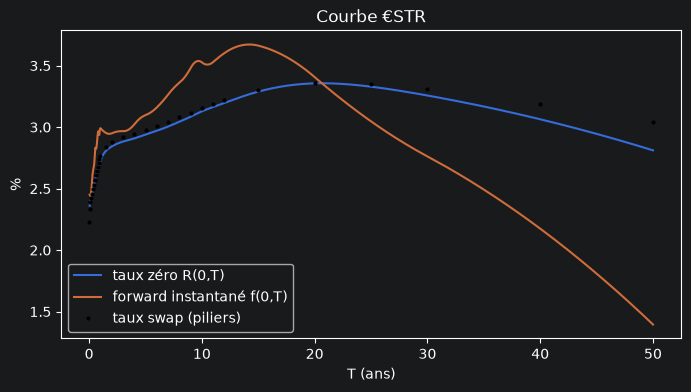

In [3]:
"""
Courbe zéro-coupon €STR : bootstrap OIS + spline cubique sur log P

"""
import numpy as np
from scipy.optimize import brentq
from scipy.interpolate import CubicSpline

def swap_dates(T):
    """Dates de paiement de la jambe fixe annuelle : T, T-1, ... > 0 (un seul flux si T <= 1)."""
    return np.arange(T, 0, -1)[::-1]

class zc_curve:

    def __init__(self, T, swap):
        T_zc, R_zc = [], []
        for Ti, S in zip(T, swap):
            dates = swap_dates(Ti)
            tau = np.diff(np.concatenate(([0.0], dates)))
            def residual(r):                                  # r = R(Ti), l'inconnue
                R = np.interp(dates, T_zc + [Ti], R_zc + [r])
                P = np.exp(-R * dates)
                return S * np.sum(tau * P) + P[-1] - 1
            R_zc.append(brentq(residual, -0.1, 0.5))
            T_zc.append(Ti)
        self.T, self.R, self.swap = np.array(T_zc), np.array(R_zc), np.asarray(swap, float)
        self._logP = CubicSpline(np.r_[0.0, self.T], np.r_[0.0, -self.R * self.T])

    def df(self, T):                                          # P^M(0, T)
        return np.exp(self._logP(T))

    def fwd(self, T):                                         # f^M(0, T) = -d/dT log P
        return -self._logP(T, 1)

    def zero(self, T):                                        # taux zéro continu
        T = np.asarray(T, float)
        return -self._logP(T) / np.where(T > 0, T, 1.0)

    def swap_rate(self, T):                                   # taux swap re-pricé par la courbe
        dates = swap_dates(T)
        tau = np.diff(np.concatenate(([0.0], dates)))
        return (1 - self.df(T)) / np.sum(tau * self.df(dates))

curve = zc_curve(estr["T"].values, estr["swap"].values)

# --- vérification 1 : la courbe re-price les swaps de calibration
repricing = np.array([curve.swap_rate(T) for T in curve.T])
print(f"re-pricing des {len(curve.T)} swaps : max |S_courbe - S_marché| = {np.max(np.abs(repricing - curve.swap)):.1e}")

# --- vérification 2 : forward = -dlogP/dT par différences finies, et régularité du forward
T, h = np.linspace(0.1, 49.9, 500), 1e-5
f_fd = -(np.log(curve.df(T + h)) - np.log(curve.df(T - h))) / (2 * h)
print(f"max |f^M - différences finies| = {np.max(np.abs(curve.fwd(T) - f_fd)):.1e}")
print(pd.DataFrame({"T": [1, 2, 5, 10, 20, 30, 40, 50]}).assign(swap=lambda d: [curve.swap_rate(T) for T in d["T"]],
      zero=lambda d: curve.zero(d["T"]), fwd=lambda d: curve.fwd(d["T"])).set_index("T").T.map("{:.4%}".format).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
T = np.linspace(0.05, 50, 1000)
ax.plot(T, curve.zero(T) * 100, label="taux zéro R(0,T)"); ax.plot(T, curve.fwd(T) * 100, label="forward instantané f(0,T)")
ax.plot(curve.T, curve.swap * 100, "k.", ms=4, label="taux swap (piliers)"); ax.set_xlabel("T (ans)"); ax.set_ylabel("%"); ax.legend(); ax.set_title("Courbe €STR")
plt.show()

## 3. Courbe OAT (zéro-coupons risqués)

La courbe $\bar P^M(0,T)$ est la courbe d'actualisation qui re-price les OAT. Les maturités des titres
sont irrégulières et le modèle a besoin d'un forward risqué $\bar f^M(0,t)$ régulier : on ajuste donc un
paramétrage lisse plutôt qu'un bootstrap. On retient **Nelson-Siegel-Svensson** sur le taux zéro continu,

$$\bar R(T) = \beta_0 + \beta_1\,\frac{1-e^{-T/\lambda_1}}{T/\lambda_1}
+ \beta_2\Big(\frac{1-e^{-T/\lambda_1}}{T/\lambda_1} - e^{-T/\lambda_1}\Big)
+ \beta_3\Big(\frac{1-e^{-T/\lambda_2}}{T/\lambda_2} - e^{-T/\lambda_2}\Big),
\qquad \bar P^M(0,T) = e^{-\bar R(T)\,T},$$

six paramètres pour dix-neuf titres, ajustés par moindres carrés sur les **prix dirty**. Les erreurs de
prix sont divisées par la duration du titre pour que chaque résidu soit homogène à une erreur de
rendement : sans cette pondération, les titres longs domineraient l'ajustement.

**Flux et coupon couru.** Une OAT paie un coupon annuel à la date anniversaire de sa maturité. Le coupon
couru à la date de règlement est calculé en ACT/ACT et comparé à celui exporté de Bloomberg. Les cinq titres
courts sont des zéro-coupons (BTF / OAT sans coupon). Les dates de flux sont converties en années ACT/365
depuis la date de règlement.

**Qualité de l'ajustement.** Six paramètres ne peuvent pas reproduire les particularités de l'extrême long
terme : les OAT 2050 (coupon 1,5 %) et 2072 (coupon 0,5 %) se traitent chères (demande de duration et de
convexité) et l'OAT 2057 se traite en dessous de la courbe. Les résidus se concentrent sur ces titres ; en
dessous de 20 ans, zone qui compte pour une option sur l'OAT 10 ans, ils sont de l'ordre du point de base.
Un multi-départ confirme que l'optimum est global.

**Spread.** On en déduit le spread zéro-coupon $\bar R(T) - R(T)$ et le spread forward $\bar f^M - f^M$,
c'est-à-dire la partie déterministe de la composante crédit du modèle ($\beta(t)$ à un terme de convexité
près). Le spread court peut être faible ou négatif : le taux OAT contient, outre le risque de défaut, des
primes de liquidité et de collatéral (Russo et al., p. 8), ce qui justifie un modèle gaussien où le spread
peut changer de signe.

paramètres NSS : [1.190000e-02 1.163000e-02 2.317000e-02 1.213700e-01 9.483000e-01
 1.457625e+01]
        isin  coupon     T  clean  accrued_bbg  accrued   dirty  ytm_bbg  ytm_annuel  prix_nss  erreur_prix  erreur_bp
FR0129570570  0.0000  0.05 99.868        0.000    0.000  99.868   0.0238      0.0244    99.868        0.000       -0.4
FR0129704112  0.0000  0.25 99.372        0.000    0.000  99.372   0.0253      0.0259    99.369       -0.003        1.4
FR0129704153  0.0000  0.50 98.649        0.000    0.000  98.649   0.0272      0.0278    98.656        0.007       -1.5
FR0129570646  0.0000  0.76 97.849        0.000    0.000  97.849   0.0284      0.0289    97.844       -0.005        0.7
FR0129704195  0.0000  0.99 97.121        0.000    0.000  97.121   0.0294      0.0298    97.129        0.008       -0.8
FR001400XLW2  0.0240  2.04 98.506        2.387    2.308 100.814   0.0317      0.0316   100.800       -0.014        0.7
FR0014016G71  0.0240  3.04 97.474        2.387    2.308  99.782   0.0

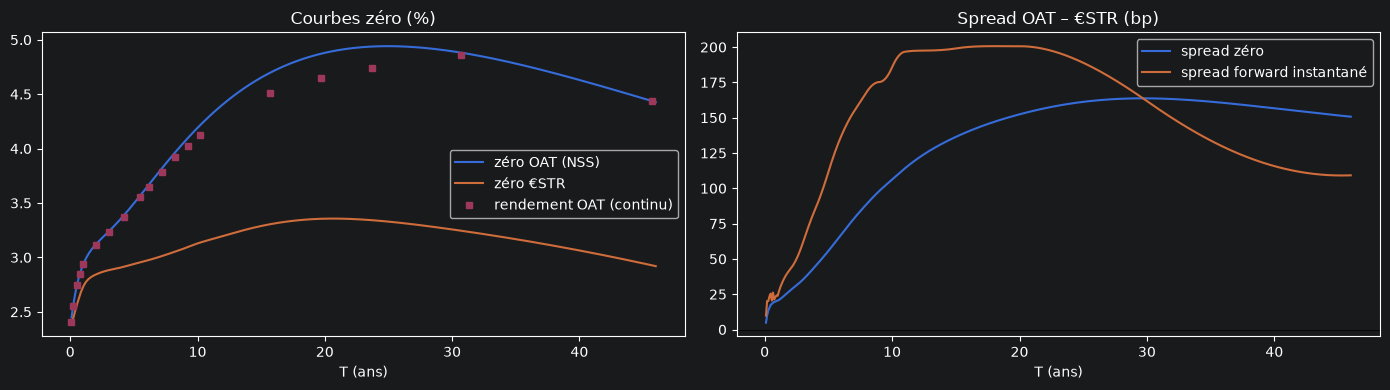

In [4]:
"""
Obligation à coupons, courbe OAT Nelson-Siegel-Svensson

"""
import numpy as np
import pandas as pd
from scipy.optimize import least_squares, brentq

class bond:

    def __init__(self, T, K):
        self.T, self.K = np.asarray(T, float), np.asarray(K, float)      # dates (années) et montants des flux

    @classmethod
    def from_dates(cls, coupon, maturity, settle=DATE_VAL):
        """Coupon annuel aux dates anniversaires de la maturité ; ACT/365 pour les temps, ACT/ACT pour le couru."""
        dates, d = [], maturity
        while d > settle:
            dates.append(d)
            d = d - pd.DateOffset(years=1)
        dates = dates[::-1]
        T = np.array([(x - settle).days / 365.0 for x in dates])
        K = np.full(len(T), coupon); K[-1] += 1.0
        b = cls(T, K)
        b.accrued = coupon * (settle - d).days / (dates[0] - d).days
        return b

    def after(self, T0):                                                  # flux strictement postérieurs à T0
        m = self.T > T0
        return bond(self.T[m], self.K[m])

    def price(self, df):                                                  # prix dirty pour une fonction d'actualisation
        return np.sum(self.K * df(self.T))

    def ytm(self, dirty):                                                 # rendement actuariel continu
        return brentq(lambda y: self.price(lambda T: np.exp(-y * T)) - dirty, -0.1, 0.5)

    def duration(self, dirty):                                            # duration de Macaulay
        y = self.ytm(dirty)
        return np.sum(self.T * self.K * np.exp(-y * self.T)) / dirty

def nss_zero(T, b):
    b0, b1, b2, b3, l1, l2 = b
    T = np.maximum(np.asarray(T, float), 1e-8)
    e1, e2 = (1 - np.exp(-T / l1)) / (T / l1), (1 - np.exp(-T / l2)) / (T / l2)
    return b0 + b1 * e1 + b2 * (e1 - np.exp(-T / l1)) + b3 * (e2 - np.exp(-T / l2))

class oat_curve:

    def __init__(self, bonds, dirty):
        dur = np.array([b.duration(p) for b, p in zip(bonds, dirty)])
        def residuals(beta):
            df = lambda T: np.exp(-nss_zero(T, beta) * T)
            return [(b.price(df) - p) / (p * d) for b, p, d in zip(bonds, dirty, dur)]   # ~ erreur de rendement
        self.fit = least_squares(residuals, x0=[0.04, -0.02, 0.0, 0.0, 2.0, 10.0],
                                 bounds=([-1, -1, -1, -1, 0.1, 0.5], [1, 1, 1, 1, 10, 50]))
        self.beta = self.fit.x

    def zero(self, T):
        return nss_zero(T, self.beta)

    def df(self, T):
        return np.exp(-self.zero(T) * np.asarray(T, float))

    def fwd(self, T, h=1e-5):                                             # f = -d/dT log P (différences centrées)
        return -(np.log(self.df(T + h)) - np.log(self.df(T - h))) / (2 * h)

# --- flux, coupon couru, prix dirty
oat["bond"] = [bond.from_dates(c, m) for c, m in zip(oat["coupon"], oat["maturity"])]
oat["T"] = [b.T[-1] for b in oat["bond"]]
oat["accrued"] = [b.accrued * 100 for b in oat["bond"]]
oat["dirty"] = oat["clean"] + oat["accrued"]
oat["ytm"] = [b.ytm(p / 100) for b, p in zip(oat["bond"], oat["dirty"])]
oat["ytm_annuel"] = np.expm1(oat["ytm"])                                  # continu -> annuel (convention Bloomberg)

# --- ajustement NSS et re-pricing
risky = oat_curve(oat["bond"].tolist(), (oat["dirty"] / 100).values)
oat["prix_nss"] = [b.price(risky.df) * 100 for b in oat["bond"]]
oat["erreur_prix"] = oat["prix_nss"] - oat["dirty"]
oat["erreur_bp"] = [(b.ytm(p / 100) - y) * 1e4 for b, p, y in zip(oat["bond"], oat["prix_nss"], oat["ytm"])]

print("paramètres NSS :", np.round(risky.beta, 5))
print(oat[["isin", "coupon", "T", "clean", "accrued_bbg", "accrued", "dirty", "ytm_bbg", "ytm_annuel", "prix_nss", "erreur_prix", "erreur_bp"]]
      .round({"coupon": 4, "T": 2, "accrued": 3, "dirty": 3, "ytm_bbg": 4, "ytm_annuel": 4, "prix_nss": 3, "erreur_prix": 3, "erreur_bp": 1}).to_string(index=False))
print(f"\nRMSE de re-pricing : {np.sqrt(np.mean(oat['erreur_prix']**2)):.3f} (prix pour 100)   {np.sqrt(np.mean(oat['erreur_bp']**2)):.1f} bp de rendement")
print(f"coupon couru recalculé vs Bloomberg : écart max = {np.max(np.abs(oat['accrued'] - oat['accrued_bbg'])):.3f} "
      f"(Bloomberg semble calculé pour un règlement 12 jours plus tard ; on garde le couru ACT/ACT au 10/09/2026)")
print(f"rendement annuel recalculé vs Bloomberg : écart max = {np.max(np.abs(oat['ytm_annuel'] - oat['ytm_bbg'])) * 1e4:.1f} bp")

T = np.linspace(0.1, 46, 500)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(T, risky.zero(T) * 100, label="zéro OAT (NSS)"); ax[0].plot(T, curve.zero(T) * 100, label="zéro €STR")
ax[0].plot(oat["T"], oat["ytm"] * 100, "s", ms=4, label="rendement OAT (continu)"); ax[0].legend(); ax[0].set_title("Courbes zéro (%)"); ax[0].set_xlabel("T (ans)")
ax[1].plot(T, (risky.zero(T) - curve.zero(T)) * 1e4, label="spread zéro")
ax[1].plot(T, (risky.fwd(T) - curve.fwd(T)) * 1e4, label="spread forward instantané"); ax[1].axhline(0, color="k", lw=0.5)
ax[1].legend(); ax[1].set_title("Spread OAT – €STR (bp)"); ax[1].set_xlabel("T (ans)")
plt.tight_layout(); plt.show()

## 4. Briques gaussiennes

Les deux facteurs sont des processus d'Ornstein-Uhlenbeck centrés (Russo éq. 12-14) :

$$dx = -a_x\,x\,dt + \sigma_x\,dW_x,\qquad dy = -a_y\,y\,dt + \sigma_y\,dW_y,\qquad
dW_x\,dW_y = \rho\,dt,\qquad x(0) = y(0) = 0.$$

Toutes les formules du modèle se ramènent à des moments gaussiens de $\big(x(T),\,y(T),\,\int_t^T x,\,\int_t^T y\big)$
conditionnels à $\mathcal F_t$. Avec $\tau = T-t$ et pour un facteur de paramètres $(a,\sigma)$ :

$$H_a(t,T) = \frac{1-e^{-a\tau}}{a}, \qquad
\mathbb E\Big[\int_t^T x\,du\,\Big|\,\mathcal F_t\Big] = H_{a_x}(t,T)\,x(t), \qquad
\mathrm{Var}\Big[\int_t^T x\,du\Big] = V_{a,\sigma}(t,T) = \frac{\sigma^2}{a^2}\Big[\tau + \frac{2}{a}e^{-a\tau} - \frac{1}{2a}e^{-2a\tau} - \frac{3}{2a}\Big],$$

$$\mathrm{Var}\,x(T) = \sigma_x^2\,\frac{1-e^{-2a_x\tau}}{2a_x},\qquad
\mathrm{Cov}\big(x(T),y(T)\big) = \rho\sigma_x\sigma_y\,\frac{1-e^{-(a_x+a_y)\tau}}{a_x+a_y},$$

$$\mathrm{Cov}\Big(x(T),\int_t^T x\Big) = \frac{\sigma_x^2}{2a_x^2}\big(1-e^{-a_x\tau}\big)^2,\qquad
\mathrm{Cov}\Big(y(T),\int_t^T x\Big) = \frac{\rho\sigma_x\sigma_y}{a_x}\Big[\frac{1-e^{-a_y\tau}}{a_y} - \frac{1-e^{-(a_x+a_y)\tau}}{a_x+a_y}\Big].$$

Le terme croisé de Russo (éq. 20) est deux fois la covariance des intégrales :

$$V_{xy}(t,T) = 2\,\mathrm{Cov}\Big(\int_t^T x,\ \int_t^T y\Big)
= \frac{2\rho\sigma_x\sigma_y}{a_x a_y}\Big[\tau - H_{a_x} - H_{a_y} + \frac{1-e^{-(a_x+a_y)\tau}}{a_x+a_y}\Big],
\qquad \bar V = V_x + V_y + V_{xy} = \mathrm{Var}\Big[\int_t^T (x + y)\,du\Big].$$

On vérifie que $G_x = e^{V_x/2}$, $G_y = e^{V_y/2}$ et $C_{xy} = e^{V_{xy}/2}$ (Russo éq. 20-22, avec
$L\sigma_y^{Russo} \to \sigma_y$), ce
qui permet d'écrire les prix de zéro-coupons de façon compacte. Les paramètres sont regroupés dans un
petit objet `params` passé explicitement à toutes les fonctions.

In [5]:
"""
Briques gaussiennes : H, V, terme croisé, moments du vecteur (x(T), y(T), int x, int y)

"""
import numpy as np
from dataclasses import dataclass, replace

@dataclass(frozen=True)
class params:
    a_x: float; s_x: float; a_y: float; s_y: float; rho: float

def H(a, t, T):
    return -np.expm1(-a * (T - t)) / a

def V(a, s, t, T):
    tau = T - t
    return s**2 / a**2 * (tau + 2 / a * np.exp(-a * tau) - np.exp(-2 * a * tau) / (2 * a) - 3 / (2 * a))

def V_xy(p, t, T):
    tau = T - t
    return 2 * p.rho * p.s_x * p.s_y / (p.a_x * p.a_y) * (tau - H(p.a_x, t, T) - H(p.a_y, t, T) - np.expm1(-(p.a_x + p.a_y) * tau) / (p.a_x + p.a_y))

def V_bar(p, t, T):
    return V(p.a_x, p.s_x, t, T) + V(p.a_y, p.s_y, t, T) + V_xy(p, t, T)

def var_factor(a, s, t, T):                     # Var x(T) | F_t
    return s**2 * -np.expm1(-2 * a * (T - t)) / (2 * a)

def cov_xy(p, t, T):                            # Cov(x(T), y(T))
    return p.rho * p.s_x * p.s_y * -np.expm1(-(p.a_x + p.a_y) * (T - t)) / (p.a_x + p.a_y)

def cov_factor_int(a, s, t, T):                 # Cov(x(T), int_t^T x)
    return s**2 / (2 * a**2) * (-np.expm1(-a * (T - t)))**2

def cov_cross_int(p, t, T):                     # Cov(y(T), int_t^T x)  (échanger x et y pour Cov(x(T), int y))
    tau = T - t
    return p.rho * p.s_x * p.s_y / p.a_x * (-np.expm1(-p.a_y * tau) / p.a_y + np.expm1(-(p.a_x + p.a_y) * tau) / (p.a_x + p.a_y))

def swap_xy(p):
    return replace(p, a_x=p.a_y, s_x=p.s_y, a_y=p.a_x, s_y=p.s_x)

# --- vérifications par quadrature (t = 0, T = 10) sur un jeu de paramètres arbitraire
from scipy.integrate import quad
p0 = params(a_x=0.03, s_x=0.008, a_y=0.25, s_y=0.02, rho=-0.3)
T = 10.0
tests = {
    "V_x        = s_x^2 int H_x(u,T)^2 du":            (V(p0.a_x, p0.s_x, 0, T), quad(lambda u: p0.s_x**2 * H(p0.a_x, u, T)**2, 0, T)[0]),
    "V_xy       = 2 rho s_x s_y int H_x H_y du":       (V_xy(p0, 0, T), quad(lambda u: 2 * p0.rho * p0.s_x * p0.s_y * H(p0.a_x, u, T) * H(p0.a_y, u, T), 0, T)[0]),
    "Var x(T)   = s_x^2 int e^{-2a_x(T-u)} du":       (var_factor(p0.a_x, p0.s_x, 0, T), quad(lambda u: p0.s_x**2 * np.exp(-2 * p0.a_x * (T - u)), 0, T)[0]),
    "Cov(x,y)   = rho s_x s_y int e^{-(a_x+a_y)(T-u)}": (cov_xy(p0, 0, T), quad(lambda u: p0.rho * p0.s_x * p0.s_y * np.exp(-(p0.a_x + p0.a_y) * (T - u)), 0, T)[0]),
    "Cov(x,intx)= s_x^2 int e^{-a_x(T-u)} H_x(u,T)":   (cov_factor_int(p0.a_x, p0.s_x, 0, T), quad(lambda u: p0.s_x**2 * np.exp(-p0.a_x * (T - u)) * H(p0.a_x, u, T), 0, T)[0]),
    "Cov(y,intx)= rho s_x s_y int e^{-a_y(T-u)} H_x":  (cov_cross_int(p0, 0, T), quad(lambda u: p0.rho * p0.s_x * p0.s_y * np.exp(-p0.a_y * (T - u)) * H(p0.a_x, u, T), 0, T)[0]),
}
for nom, (ferme, num) in tests.items():
    print(f"{nom:<50s} fermé = {ferme: .10f}   quadrature = {num: .10f}   écart = {abs(ferme - num):.1e}")

# --- limite a -> 0 : H -> tau, V -> s^2 tau^3 / 3
print(f"\nlimite a -> 0 :  H(1e-8, 0, 10) = {H(1e-8, 0, 10):.6f} (tau = 10)   V(1e-4, 0.01, 0, 10) = {V(1e-4, 0.01, 0, 10):.6f} (s^2 tau^3/3 = {0.01**2 * 1000 / 3:.6f})")

V_x        = s_x^2 int H_x(u,T)^2 du               fermé =  0.0171392553   quadrature =  0.0171392553   écart = 3.9e-16
V_xy       = 2 rho s_x s_y int H_x H_y du          fermé = -0.0133529232   quadrature = -0.0133529232   écart = 5.2e-18
Var x(T)   = s_x^2 int e^{-2a_x(T-u)} du           fermé =  0.0004812676   quadrature =  0.0004812676   écart = 5.4e-20
Cov(x,y)   = rho s_x s_y int e^{-(a_x+a_y)(T-u)}   fermé = -0.0001610040   quadrature = -0.0001610040   écart = 2.7e-20
Cov(x,intx)= s_x^2 int e^{-a_x(T-u)} H_x(u,T)      fermé =  0.0023884514   quadrature =  0.0023884514   écart = 0.0e+00
Cov(y,intx)= rho s_x s_y int e^{-a_y(T-u)} H_x     fermé = -0.0005078564   quadrature = -0.0005078564   écart = 0.0e+00

limite a -> 0 :  H(1e-8, 0, 10) = 10.000000 (tau = 10)   V(1e-4, 0.01, 0, 10) = 0.033308 (s^2 tau^3/3 = 0.033333)


## 5. Hull-White à un facteur : zéro-coupons, obligations, options, swaptions

Cette section traite le facteur taux seul ($\sigma_y = 0$) : c'est le modèle de l'étape 1 de calibration
(Russo éq. 53-54) et le cas limite du modèle complet.

**Recalage et prix des zéro-coupons.** $r(t) = \alpha(t) + x(t)$ avec
$\alpha(t) = f^M(0,t) + \frac{\sigma_x^2}{2a_x^2}(1-e^{-a_xt})^2$, ce qui équivaut à
$\int_0^T\alpha = -\log P^M(0,T) + \frac12 V_x(0,T)$. Comme $\int_t^T x\,du$ est gaussien de moyenne
$H_x(t,T)\,x(t)$ et de variance $V_x(t,T)$,

$$P(t,T) = \frac{P^M(0,T)}{P^M(0,t)}\,\exp\Big(-H_x(t,T)\,x(t) + \tfrac12\big[V_x(t,T) - V_x(0,T) + V_x(0,t)\big]\Big),$$

log-affine en $x(t)$, et $-\partial_x \log P(t,T) = H_x(t,T)$ est la duration stochastique du zéro-coupon.

**Obligation à coupons et duration stochastique** (Russo éq. 28-31, cas 1F). Pour des flux $K_i$ aux
dates $T_i$, $B(t) = \sum_i K_i P(t,T_i)$ et
$D_x(t) = -\partial_x \log B = \sum_i w_i(t)\,H_x(t,T_i)$ avec $w_i = K_i P(t,T_i)/B(t)$.

**Option sur obligation à coupons — approximation des poids gelés.** Sous la mesure $T_0$-forward, le
prix forward $B(t)/P(t,T_0)$ est une martingale de volatilité $\sigma_x\big[D_x(t) - H_x(t,T_0)\big]$.
Si l'on gèle les poids $w_i$ à leur valeur en $t$ (Russo & Fabozzi 2016), $\log B(T_0)$ est gaussien :
$H_x(u,T_i) - H_x(u,T_0) = e^{-a_x(T_0-u)}H_x(T_0,T_i)$, donc

$$\Sigma_B^2 = \int_t^{T_0}\sigma_x^2\big[D_x(u)-H_x(u,T_0)\big]^2du \approx \bar D_x^2\,\mathrm{Var}\,x(T_0),
\qquad \bar D_x = \sum_i w_i(t)\,H_x(T_0,T_i),$$

et le prix est donné par la formule de Black : $C = B(t)\Phi(d_1) - X P(t,T_0)\Phi(d_2)$,
$d_{1,2} = \big[\log\frac{B(t)}{XP(t,T_0)} \pm \frac12\Sigma_B^2\big]/\Sigma_B$, où $B(t)$ ne somme que les
flux postérieurs à $T_0$. Russo écrit cette variance comme une intégrale à évaluer numériquement ; avec les
poids gelés elle est fermée, et l'on garde la quadrature de Gauss-Legendre comme contrôle.

**Contrôle exact : Jamshidian (1989).** En 1F, le prix d'une option sur obligation à coupons est exact :
on cherche $x^\ast$ tel que $B(T_0, x^\ast) = X$, et l'option se décompose en une somme d'options sur
zéro-coupons de strikes $X_i = P(T_0,T_i,x^\ast)$, chacune ayant une formule fermée dans Hull-White
($\sigma_P = \sigma_x H_x(T_0,T_i)\sqrt{(1-e^{-2a_xT_0})/2a_x}$). L'écart entre Black à poids gelés et
Jamshidian mesure le coût de l'approximation que l'on emporte ensuite en deux facteurs, où Jamshidian ne
s'applique plus.

**Swaptions.** Une swaption payeuse d'expiry $T_0$ et de tenor $n$ est un put de strike 1 sur l'obligation
« jambe fixe + nominal » de flux $S\tau_i$ aux dates $T_0 + 1, \dots, T_0 + n$. À la monnaie, le prix de
marché en vol normale $\sigma_N$ (Bachelier) est $A\,\sigma_N\sqrt{T_0/2\pi}$ avec $A$ l'annuité, et payeuse
= receveuse.

In [6]:
"""
Modèle de Hull & White à un facteur

"""
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

def black(F, X, sigma, call=True):
    """Formule de Black (prix forward, non actualisé) ; sigma = écart-type total de log F."""
    if sigma < 1e-12:
        return max(F - X, 0.0) if call else max(X - F, 0.0)
    d1 = (np.log(F / X) + 0.5 * sigma**2) / sigma
    d2 = d1 - sigma
    return F * norm.cdf(d1) - X * norm.cdf(d2) if call else X * norm.cdf(-d2) - F * norm.cdf(-d1)

class hw1f_model:

    def __init__(self, curve, a, sigma):
        self.curve, self.a, self.sigma = curve, a, sigma

    def V(self, t, T):
        return V(self.a, self.sigma, t, T)

    def alpha(self, t):
        return self.curve.fwd(t) + self.sigma**2 / (2 * self.a**2) * (-np.expm1(-self.a * t))**2

    def P(self, t, T, x):
        return self.curve.df(T) / self.curve.df(t) * np.exp(-H(self.a, t, T) * x + 0.5 * (self.V(t, T) - self.V(0, T) + self.V(0, t)))

    def bond_price(self, t, bd, x):
        return np.sum(bd.K * self.P(t, bd.T, x))

    def duration(self, t, bd, x):
        w = bd.K * self.P(t, bd.T, x)
        return np.sum(w * H(self.a, t, bd.T)) / np.sum(w)

    def sigma_B(self, t, T0, bd, x=0.0):
        """Ecart-type de log B(T0) sous poids gelés (forme fermée)."""
        bd = bd.after(T0)
        w = bd.K * self.P(t, bd.T, x); w /= w.sum()
        return np.sum(w * H(self.a, T0, bd.T)) * np.sqrt(var_factor(self.a, self.sigma, t, T0))

    def sigma_B_quad(self, t, T0, bd, x=0.0, n=32):
        """Même quantité par quadrature de Gauss-Legendre de int sigma^2 [D_x(u) - H(u,T0)]^2 du (poids gelés)."""
        bd = bd.after(T0)
        w = bd.K * self.P(t, bd.T, x); w /= w.sum()
        u, wq = np.polynomial.legendre.leggauss(n)
        u, wq = t + (T0 - t) * (u + 1) / 2, wq * (T0 - t) / 2
        D = np.sum(w * (H(self.a, u[:, None], bd.T) - H(self.a, u[:, None], T0)), axis=1)
        return np.sqrt(np.sum(wq * self.sigma**2 * D**2))

    def bond_option(self, t, T0, bd, X, x=0.0, call=True):
        """Option européenne sur obligation à coupons, Black à poids gelés (Russo & Fabozzi 2016)."""
        bd = bd.after(T0)
        F = self.bond_price(t, bd, x) / self.P(t, T0, x)
        return self.P(t, T0, x) * black(F, X, self.sigma_B(t, T0, bd, x), call)

    def zc_option(self, T0, T, X, call=True):
        """Option sur zéro-coupon P(T0,T), formule exacte de Hull-White (t = 0, x = 0)."""
        sp = self.sigma * H(self.a, T0, T) * np.sqrt(var_factor(self.a, 1.0, 0, T0))
        return self.curve.df(T0) * black(self.curve.df(T) / self.curve.df(T0), X, sp, call)

    def jamshidian(self, T0, bd, X, call=True):
        """Option sur obligation à coupons, décomposition exacte de Jamshidian (t = 0, x = 0)."""
        bd = bd.after(T0)
        x_star = brentq(lambda x: self.bond_price(T0, bd, x) - X, -3.0, 3.0)
        return np.sum([K * self.zc_option(T0, T, self.P(T0, T, x_star), call) for K, T in zip(bd.K, bd.T)])

# --- swaps et swaptions sur la courbe sans risque
def swap_bond(T0, tenor, S):
    """Obligation « jambe fixe + nominal » : flux S * tau_i aux dates T0 + 1, ..., T0 + tenor."""
    T = T0 + np.arange(1.0, tenor + 1)
    K = S * np.diff(np.concatenate(([T0], T))); K[-1] += 1.0
    return bond(T, K)

def annuity(curve, T0, tenor):
    T = T0 + np.arange(1.0, tenor + 1)
    return np.sum(np.diff(np.concatenate(([T0], T))) * curve.df(T))

def atm_rate(curve, T0, tenor):
    return (curve.df(T0) - curve.df(T0 + tenor)) / annuity(curve, T0, tenor)

def bachelier_atm(curve, T0, tenor, vol):
    return annuity(curve, T0, tenor) * vol * np.sqrt(T0 / (2 * np.pi))

def swaption(model, T0, tenor, payer=True, S=None, exact=False):
    """Swaption = option de strike 1 sur l'obligation jambe fixe (payeuse = put). exact = Jamshidian."""
    S = atm_rate(model.curve, T0, tenor) if S is None else S
    bd = swap_bond(T0, tenor, S)
    return model.jamshidian(T0, bd, 1.0, call=not payer) if exact else model.bond_option(0.0, T0, bd, 1.0, 0.0, call=not payer)

In [7]:
hw = hw1f_model(curve, a=0.03, sigma=0.008)
oat10 = oat["bond"][oat["isin"] == "FR0014018YR0"].iloc[0]           # OAT 3.70 % 25/11/2036, sous-jacent cible

# --- 1. recalage exact de la courbe et duration
T = np.array([1, 2, 5, 10, 20, 30.0])
print("recalage : max |P(0,T,0) - P^M(0,T)| =", f"{np.max(np.abs(hw.P(0, T, 0.0) - curve.df(T))):.1e}")
h = 1e-6
print("-dlogP/dx vs H : max écart =", f"{np.max(np.abs(-(np.log(hw.P(1, T + 1, h)) - np.log(hw.P(1, T + 1, -h))) / (2 * h) - H(hw.a, 1, T + 1))):.1e}")
print("alpha(t) vs d/dT[-log P^M + V/2] :", f"{np.max(np.abs(hw.alpha(T) - (-(np.log(curve.df(T + h)) - np.log(curve.df(T - h))) / (2 * h) + (hw.V(0, T + h) - hw.V(0, T - h)) / (4 * h)))):.1e}")
print(f"OAT 3.70 % 2036 : prix = {hw.bond_price(0, oat10, 0.0) * 100:.3f} (sur courbe €STR)   D_x = {hw.duration(0, oat10, 0.0):.3f}   "
      f"-dlogB/dx (diff. finies) = {-(np.log(hw.bond_price(0, oat10, h)) - np.log(hw.bond_price(0, oat10, -h))) / (2 * h):.3f}")

# --- 2. Sigma_B fermé vs quadrature, cas d'un seul flux = zéro-coupon
print(f"\nSigma_B(0, 5, OAT 2036) : fermé = {hw.sigma_B(0, 5, oat10):.8f}   quadrature = {hw.sigma_B_quad(0, 5, oat10):.8f}")
zc = bond([10.0], [1.0])
print(f"un seul flux (ZC 10 ans, option 5 ans) : Sigma_B = {hw.sigma_B(0, 5, zc):.8f}   sigma_P Hull-White = {hw.sigma * H(hw.a, 5, 10) * np.sqrt(var_factor(hw.a, 1, 0, 5)):.8f}")

# --- 3. parité call-put, limite sigma -> 0, Jamshidian
T0, X = 2.0, 1.0
C, Pt = hw.bond_option(0, T0, oat10, X), hw.bond_option(0, T0, oat10, X, call=False)
Bf = hw.bond_price(0, oat10.after(T0), 0.0)
print(f"\nparité : C - P = {C - Pt:.8f}   B(0) - X P(0,T0) = {Bf - X * curve.df(T0):.8f}")
hw0 = hw1f_model(curve, a=0.03, sigma=1e-9)
print(f"sigma -> 0 : call = {hw0.bond_option(0, T0, oat10, X):.8f}   valeur intrinsèque actualisée = {max(Bf - X * curve.df(T0), 0):.8f}")
print("\nBlack à poids gelés vs Jamshidian (call sur l'OAT 2036, prix pour 100) :")
for T0 in [1.0, 2.0, 5.0]:
    F = hw.bond_price(0, oat10.after(T0), 0.0) / curve.df(T0)
    for k in [0.95, 1.0, 1.05]:
        X = k * F
        print(f"  T0 = {T0:.0f}  X = {k:.0%} du forward : gelé = {hw.bond_option(0, T0, oat10, X) * 100:.4f}   Jamshidian = {hw.jamshidian(T0, oat10, X) * 100:.4f}"
              f"   écart = {(hw.bond_option(0, T0, oat10, X) / hw.jamshidian(T0, oat10, X) - 1) * 100:+.2f} %")

# --- 4. swaptions : ATM -> payeuse = receveuse, comparaison au marché
print("\nswaptions ATM (prix pour un nominal de 1) :")
for T0, n in [(1, 10), (5, 5), (10, 10)]:
    S = atm_rate(curve, T0, n)
    print(f"  {T0:>2}Y x {n:>2}Y  S_atm = {S:.4%}  payeuse = {swaption(hw, T0, n):.6f}  receveuse = {swaption(hw, T0, n, payer=False):.6f}"
          f"  Jamshidian = {swaption(hw, T0, n, exact=True):.6f}  marché (Bachelier) = {bachelier_atm(curve, T0, n, cube.loc[T0, n]):.6f}")

recalage : max |P(0,T,0) - P^M(0,T)| = 0.0e+00
-dlogP/dx vs H : max écart = 5.6e-11
alpha(t) vs d/dT[-log P^M + V/2] : 2.7e-10
OAT 3.70 % 2036 : prix = 107.532 (sur courbe €STR)   D_x = 7.378   -dlogB/dx (diff. finies) = 7.378

Sigma_B(0, 5, OAT 2036) : fermé = 0.07266301   quadrature = 0.07266301
un seul flux (ZC 10 ans, option 5 ans) : Sigma_B = 0.07720076   sigma_P Hull-White = 0.07720076

parité : C - P = 0.05799285   B(0) - X P(0,T0) = 0.05799285
sigma -> 0 : call = 0.05799285   valeur intrinsèque actualisée = 0.05799285

Black à poids gelés vs Jamshidian (call sur l'OAT 2036, prix pour 100) :
  T0 = 1  X = 95% du forward : gelé = 5.6927   Jamshidian = 5.6886   écart = +0.07 %
  T0 = 1  X = 100% du forward : gelé = 2.2364   Jamshidian = 2.2363   écart = +0.00 %
  T0 = 1  X = 105% du forward : gelé = 0.5729   Jamshidian = 0.5769   écart = -0.70 %
  T0 = 2  X = 95% du forward : gelé = 5.9096   Jamshidian = 5.9041   écart = +0.09 %
  T0 = 2  X = 100% du forward : gelé = 2.7618   Jams

## 6. Calibration étape 1 : $(a_x,\sigma_x)$ sur les swaptions ATM

Suivant Russo et al. (éq. 55) et Russo & Fabozzi (2016), on minimise la racine de la somme des carrés des
erreurs relatives de prix :

$$\min_{a_x,\sigma_x}\ \sqrt{\sum_{i=1}^{N_1}\Big(\frac{Swpt_i - Swpt_i^M}{Swpt_i^M}\Big)^2},$$

par L-BFGS-B avec bornes $a_x \in [0.001, 1]$, $\sigma_x \in [10^{-4}, 0.05]$. Les prix de marché sont les
prix Bachelier ATM ; les prix modèle sont les puts à poids gelés de la section 5, exactement comme dans
Russo (la méthode qui s'étend au 2F). Comme les prix ATM sont linéaires en vol normale, l'erreur relative
de prix est aussi l'erreur relative de vol, et on exprime les résidus en points de base de vol normale.

Deux jeux de calibration :

1. **la surface complète** (291 swaptions, en excluant $T_0 + n > 50$ ans, au-delà de la courbe) : un
   modèle à un facteur et deux paramètres constants ne peut pas la reproduire ; la carte des résidus
   montre où se situe l'erreur structurelle ;
2. **la diagonale co-terminale** $T_0 + n = T^\star$ avec $T^\star$ la maturité de l'OAT sous-jacente
   (Russo et al. utilisent des swaptions co-terminales « pour des raisons de couverture ») : les
   swaptions dont le swap sous-jacent se termine à la maturité de l'obligation portent l'information
   sur la volatilité des taux qui compte pour l'option. On impose $T_0 \ge 1$ an, les vols très courtes
   étant dominées par la politique monétaire.

Sur la diagonale, la vitesse de retour $a_x$ n'est pas toujours identifiée : la vol normale y est presque
plate en expiry et l'optimum peut se coller à la borne. La vitesse de retour est identifiée par la
structure expiry × tenor de la surface entière ; on retient donc **$a_x$ de la surface** et l'on recalibre
**$\sigma_x$ seul sur la diagonale co-terminale**, ce qui garantit que les swaptions qui couvrent l'option
sont re-pricées. On vérifie la stabilité de l'optimum vis-à-vis du point de départ, et on quantifie sur la
diagonale l'erreur de l'approximation des poids gelés grâce à Jamshidian.

In [8]:
"""
Calibration de (a_x, sigma_x) sur les swaptions ATM

"""
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def swaption_table(curve, cube, T_max=50):
    tab = cube.stack().reset_index()
    tab.columns = ["T0", "tenor", "vol"]
    tab = tab[tab["T0"] + tab["tenor"] <= T_max].reset_index(drop=True)
    tab["prix_mkt"] = [bachelier_atm(curve, T0, n, v) for T0, n, v in zip(tab["T0"], tab["tenor"], tab["vol"])]
    return tab

def model_prices(curve, a, sigma, tab, exact=False):
    m = hw1f_model(curve, a, sigma)
    return np.array([swaption(m, T0, n, exact=exact) for T0, n in zip(tab["T0"], tab["tenor"])])

def objective(x, curve, tab):
    return np.sqrt(np.sum(((model_prices(curve, x[0], x[1], tab) - tab["prix_mkt"]) / tab["prix_mkt"])**2))

def calibrate(curve, tab, x0=(0.05, 0.01)):
    return minimize(objective, x0=list(x0), args=(curve, tab), method="L-BFGS-B", bounds=[(0.001, 1), (1e-4, 0.05)])

def residuals(curve, a, sigma, tab):
    tab = tab.copy()
    tab["prix_mod"] = model_prices(curve, a, sigma, tab)
    tab["residu"] = tab["prix_mod"] / tab["prix_mkt"] - 1
    tab["residu_bp"] = tab["vol"] * tab["residu"] * 1e4               # Bachelier ATM : prix linéaire en vol
    return tab

def coterminal(tab, T_star, T0_min=1.0):
    """Swaptions dont le swap sous-jacent se termine en T_star (arrondi à l'année), expiry >= T0_min."""
    return tab[np.isclose(tab["T0"] + tab["tenor"], round(T_star)) & (tab["T0"] >= T0_min)]

swaptions = swaption_table(curve, cube)
print(f"{len(swaptions)} swaptions retenues sur {cube.size}")

# --- 1. surface complète
res_full = calibrate(curve, swaptions)
tab_full = residuals(curve, *res_full.x, swaptions)
print(f"\nSURFACE COMPLÈTE : a_x = {res_full.x[0]:.5f}   sigma_x = {res_full.x[1]:.4%}   RMSE relatif = {res_full.fun / np.sqrt(len(swaptions)):.2%}"
      f"   RMSE vol = {np.sqrt(np.mean(tab_full['residu_bp']**2)):.1f} bp   ({res_full.nfev} évaluations)")
print("résidus de vol (modèle - marché, bp) — lignes = expiry, colonnes = tenor :")
print(tab_full.pivot(index="T0", columns="tenor", values="residu_bp").round(1).to_string())

# --- 2. stabilité multi-départs (surface)
print("\nstabilité selon le point de départ (surface) :")
for x0 in [(0.05, 0.01), (0.005, 0.002), (0.5, 0.03), (0.2, 0.002)]:
    r = calibrate(curve, swaptions, x0)
    print(f"  départ {x0} -> a_x = {r.x[0]:.5f}   sigma_x = {r.x[1]:.4%}   objectif = {r.fun:.5f}")

291 swaptions retenues sur 294

SURFACE COMPLÈTE : a_x = 0.01380   sigma_x = 0.7361%   RMSE relatif = 7.20%   RMSE vol = 4.5 bp   (57 évaluations)
résidus de vol (modèle - marché, bp) — lignes = expiry, colonnes = tenor :
tenor      1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0  15.0  20.0  25.0  30.0
T0                                                                                           
0.083333   14.7   1.7   2.7   5.3   8.3   9.7  10.7  11.6  12.2  12.7  13.8  14.1  14.1  13.8
0.166667   11.1   0.5   1.6   3.4   5.4   6.8   7.8   8.7   9.5  10.0  11.1  11.8  12.0  12.0
0.250000    6.4  -1.8  -0.1   1.6   3.4   4.7   5.5   6.3   6.9   7.5   8.3   9.4   9.6   9.9
0.500000   -0.2  -5.0  -2.8  -0.9   0.8   1.6   2.4   3.1   3.6   4.1   4.5   5.3   5.5   5.3
0.750000   -4.9  -7.6  -5.2  -3.3  -1.6  -0.8  -0.1   0.7   1.3   2.0   2.2   2.9   2.9   2.3
1.000000   -7.4  -8.8  -6.4  -5.0  -3.5  -2.7  -1.9  -1.1  -0.5   0.1   0.3   0.5   0.4  -0.2
1.500000   -8.6  -8.5  -6.

maturité de l'OAT cible : T* = 10.22 ans
  T* =  5 :  4 swaptions  a_x = 0.00100   sigma_x = 0.7726%   RMSE relatif = 0.89%   <- a_x à la borne inférieure
  T* = 10 :  9 swaptions  a_x = 0.00100   sigma_x = 0.7234%   RMSE relatif = 1.39%   <- a_x à la borne inférieure
  T* = 20 :  4 swaptions  a_x = 0.02839   sigma_x = 0.8605%   RMSE relatif = 0.95%
  T* = 30 :  5 swaptions  a_x = 0.04419   sigma_x = 1.0843%   RMSE relatif = 0.98%
  T* = 10, multi-départ (0.005, 0.002) -> a_x = 0.00100   sigma_x = 0.7234%
  T* = 10, multi-départ (0.5, 0.03) -> a_x = 0.00100   sigma_x = 0.7234%

RETENU : a_x = 0.01380 (surface)   sigma_x = 0.7699% (diagonale 10 ans, a_x fixé)   RMSE relatif sur la diagonale = 1.44%
 T0  tenor     vol  prix_mkt  prix_mod  residu_bp  prix_jamshidian  gelé/exact - 1 (%)
1.0    9.0 0.00713  0.021434  0.022262        2.8         0.022261               0.004
2.0    8.0 0.00742  0.027590  0.027538       -0.1         0.027536               0.005
3.0    7.0 0.00747  0.029284  0.

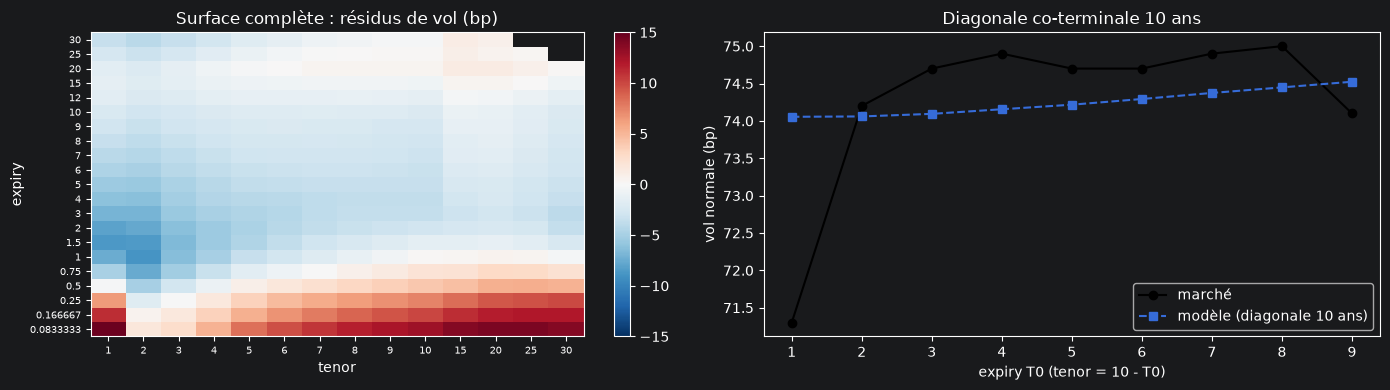

In [9]:
# --- 3. diagonales co-terminales : calibration jointe de (a_x, sigma_x)
T_star = oat10.T[-1]
print(f"maturité de l'OAT cible : T* = {T_star:.2f} ans")
res_diag = {}
for Ts in [5, 10, 20, 30]:
    jeu = coterminal(swaptions, Ts)
    r = calibrate(curve, jeu)
    res_diag[Ts] = (r, jeu)
    print(f"  T* = {Ts:>2} : {len(jeu):>2} swaptions  a_x = {r.x[0]:.5f}   sigma_x = {r.x[1]:.4%}   RMSE relatif = {r.fun / np.sqrt(len(jeu)):.2%}"
          + ("   <- a_x à la borne inférieure" if r.x[0] <= 0.0011 else ""))
jeu = res_diag[10][1]
for x0 in [(0.005, 0.002), (0.5, 0.03)]:
    r = calibrate(curve, jeu, x0)
    print(f"  T* = 10, multi-départ {x0} -> a_x = {r.x[0]:.5f}   sigma_x = {r.x[1]:.4%}")

# --- 4. la diagonale 10 ans n'identifie pas a_x : on fixe a_x à la valeur de la surface et on calibre sigma_x seul
A_X = res_full.x[0]
obj_sig = lambda z: objective([A_X, z[0]], curve, jeu)
r_sig = minimize(obj_sig, x0=[0.008], method="L-BFGS-B", bounds=[(1e-4, 0.05)])
S_X = r_sig.x[0]
tab_diag = residuals(curve, A_X, S_X, jeu)
tab_diag["prix_jamshidian"] = model_prices(curve, A_X, S_X, jeu, exact=True)
tab_diag["gelé/exact - 1 (%)"] = (tab_diag["prix_mod"] / tab_diag["prix_jamshidian"] - 1) * 100
print(f"\nRETENU : a_x = {A_X:.5f} (surface)   sigma_x = {S_X:.4%} (diagonale 10 ans, a_x fixé)   RMSE relatif sur la diagonale = {r_sig.fun / np.sqrt(len(jeu)):.2%}")
print(tab_diag[["T0", "tenor", "vol", "prix_mkt", "prix_mod", "residu_bp", "prix_jamshidian", "gelé/exact - 1 (%)"]]
      .round({"vol": 5, "prix_mkt": 6, "prix_mod": 6, "residu_bp": 1, "prix_jamshidian": 6, "gelé/exact - 1 (%)": 3}).to_string(index=False))

# --- 5. même chose avec Jamshidian (exact) : effet de l'approximation des poids gelés sur le paramètre calibré
obj_exact = lambda z: np.sqrt(np.sum(((model_prices(curve, A_X, z[0], jeu, exact=True) - jeu["prix_mkt"]) / jeu["prix_mkt"])**2))
r_ex = minimize(obj_exact, x0=[S_X], method="L-BFGS-B", bounds=[(1e-4, 0.05)])
print(f"\ncalibration exacte (Jamshidian) sur la même diagonale, a_x fixé : sigma_x = {r_ex.x[0]:.4%}   (poids gelés : {S_X:.4%})")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
piv = tab_full.pivot(index="T0", columns="tenor", values="residu_bp")
im = ax[0].imshow(piv.values, aspect="auto", cmap="RdBu_r", vmin=-15, vmax=15, origin="lower")
ax[0].set_xticks(range(len(piv.columns))); ax[0].set_xticklabels([f"{c:g}" for c in piv.columns], fontsize=7)
ax[0].set_yticks(range(len(piv.index))); ax[0].set_yticklabels([f"{i:g}" for i in piv.index], fontsize=7)
ax[0].set_xlabel("tenor"); ax[0].set_ylabel("expiry"); ax[0].set_title("Surface complète : résidus de vol (bp)"); plt.colorbar(im, ax=ax[0])
ax[1].plot(tab_diag["T0"], tab_diag["vol"] * 1e4, "ko-", label="marché")
ax[1].plot(tab_diag["T0"], (tab_diag["vol"] + tab_diag["residu_bp"] / 1e4) * 1e4, "s--", label="modèle (diagonale 10 ans)")
ax[1].set_xlabel("expiry T0 (tenor = 10 - T0)"); ax[1].set_ylabel("vol normale (bp)"); ax[1].legend(); ax[1].set_title("Diagonale co-terminale 10 ans")
plt.tight_layout(); plt.show()

## 7. Le modèle à deux facteurs

**Taux court risqué** (Russo éq. 7-14) : $\bar r(t) = \bar\alpha(t) + x(t) + y(t)$.

*Lien avec l'écriture de Russo.* Russo pose $s = L\lambda$, $\lambda = \beta + y^{R}$, $dy^{R} = -a_y y^{R}dt + \sigma_y^{R}dW_y$,
et écrit $\bar r = \bar\alpha + x + Ly^{R}$ avec $L$ la perte en cas de défaut, « input » du modèle. Comme
$\bar\alpha$ recale directement la courbe risquée, $L$ n'apparaît dans aucun prix autrement que par le
produit $L\sigma_y^{R}$ : poser $y = Ly^{R}$ et $\sigma_y = L\sigma_y^{R}$ donne le même modèle avec un
paramètre de moins. Les sensibilités à $L$ des Exhibits 6-7 de Russo sont donc des sensibilités à la
volatilité du spread, et c'est ainsi qu'on les présentera. $L$ ne compterait que pour lire $y$ comme une
intensité de défaut (probabilités de survie) ou pour une option payant le recouvrement au défaut, hors
périmètre.

Le recalage direct de la courbe OAT donne (éq. 15)

$$\bar\alpha(t) = \bar f^M(0,t) + \frac{\sigma_x^2}{2a_x^2}(1-e^{-a_xt})^2 + \frac{\sigma_y^2}{2a_y^2}(1-e^{-a_yt})^2
+ \frac{\rho\sigma_x\sigma_y}{a_xa_y}(1-e^{-a_xt})(1-e^{-a_yt}),$$

soit, sous forme intégrée (c'est ce que l'on code, plus stable) : $\int_0^T\bar\alpha = -\log\bar P^M(0,T) + \frac12\bar V(0,T)$.
La différence $\bar\alpha - \alpha = \beta$ est le spread forward de marché plus les convexités crédit et croisée.

**Zéro-coupon risqué** (éq. 16-24). $\int_t^T(x+y)\,du$ est gaussien de moyenne $H_x x(t) + H_y y(t)$ et
de variance $\bar V(t,T)$, d'où

$$\bar P(t,T) = \frac{\bar P^M(0,T)}{\bar P^M(0,t)}\exp\Big(-H_x(t,T)\,x(t) - H_y(t,T)\,y(t)
+ \tfrac12\big[\bar V(t,T) - \bar V(0,T) + \bar V(0,t)\big]\Big).$$

C'est exactement $\frac{\bar P^M(0,T)}{\bar P^M(0,t)}\frac{P_{xy}(0,t)}{P_{xy}(0,T)}P_{xy}(t,T)$ de Russo avec
$P_{xy} = G_xG_yC_{xy}e^{-H_xx - H_yy}$ ; les durations stochastiques sont $-\partial_x\log\bar P = H_x$ et
$-\partial_y\log\bar P = H_y$ (éq. 26-27).

**OAT à coupons** (éq. 28-31) : $\bar B(t) = \sum_i K_i\bar P(t,T_i)$,
$D_x = \sum_i w_iH_x(t,T_i)$, $D_y = \sum_i w_iH_y(t,T_i)$, $w_i = K_i\bar P(t,T_i)/\bar B(t)$.

**Volatilité du prix forward** (éq. 46-48). Avec les poids gelés, $\log\bar B(T_0) \approx c - \bar D_x\,x(T_0) - \bar D_y\,y(T_0)$
où $\bar D_\cdot = \sum_i w_i(t)H_\cdot(T_0,T_i)$, donc

$$\bar\Sigma_B^2 = \bar D_x^2\,\mathrm{Var}\,x(T_0) + \bar D_y^2\,\mathrm{Var}\,y(T_0) + 2\bar D_x\bar D_y\,\mathrm{Cov}\big(x(T_0),y(T_0)\big),$$

forme fermée de l'intégrale (47) que Russo évalue numériquement. Cette variance ne dépend pas de la mesure
(seules les moyennes changent par Girsanov), elle sert donc telle quelle dans la section suivante. Elle se
décompose en une part taux, une part crédit et une part croisée dont le signe est celui de $\rho$.

In [10]:
"""
Modèle gaussien à deux facteurs (Russo, Giacometti & Fabozzi)

"""
import numpy as np

class hw2f_model:

    def __init__(self, curve_rf, curve_risky, p):
        self.rf = hw1f_model(curve_rf, p.a_x, p.s_x)          # facteur taux seul (section 5)
        self.risky, self.p = curve_risky, p

    def V_bar(self, t, T):
        return V_bar(self.p, t, T)

    def alpha_bar(self, t):                                   # Russo éq. 15
        p = self.p
        ex, ey = -np.expm1(-p.a_x * t), -np.expm1(-p.a_y * t)
        return self.risky.fwd(t) + p.s_x**2 / (2 * p.a_x**2) * ex**2 + p.s_y**2 / (2 * p.a_y**2) * ey**2 + p.rho * p.s_x * p.s_y / (p.a_x * p.a_y) * ex * ey

    def P(self, t, T, x):                                     # zéro-coupon sans risque
        return self.rf.P(t, T, x)

    def Pbar(self, t, T, x, y):                               # zéro-coupon risqué, Russo éq. 16-24
        p = self.p
        return self.risky.df(T) / self.risky.df(t) * np.exp(-H(p.a_x, t, T) * x - H(p.a_y, t, T) * y
                                                            + 0.5 * (self.V_bar(t, T) - self.V_bar(0, T) + self.V_bar(0, t)))

    def bond_price(self, t, bd, x, y):
        return np.sum(bd.K * self.Pbar(t, bd.T, x, y))

    def durations(self, t, bd, x, y):                         # (D_x, D_y), Russo éq. 30-31
        w = bd.K * self.Pbar(t, bd.T, x, y); w /= w.sum()
        return np.sum(w * H(self.p.a_x, t, bd.T)), np.sum(w * H(self.p.a_y, t, bd.T))

    def sigma_B2_parts(self, t, T0, bd, x=0.0, y=0.0):
        """Décomposition de Sigma_B^2 (poids gelés) en parts taux, crédit et croisée."""
        p, bd = self.p, bd.after(T0)
        w = bd.K * self.Pbar(t, bd.T, x, y); w /= w.sum()
        Dx, Dy = np.sum(w * H(p.a_x, T0, bd.T)), np.sum(w * H(p.a_y, T0, bd.T))
        return (Dx**2 * var_factor(p.a_x, p.s_x, t, T0),
                Dy**2 * var_factor(p.a_y, p.s_y, t, T0),
                2 * Dx * Dy * cov_xy(p, t, T0))

    def sigma_B(self, t, T0, bd, x=0.0, y=0.0):
        return np.sqrt(sum(self.sigma_B2_parts(t, T0, bd, x, y)))

    def sigma_B_quad(self, t, T0, bd, x=0.0, y=0.0, n=32):
        """Russo éq. 47-48 par Gauss-Legendre, poids gelés en t."""
        p, bd = self.p, bd.after(T0)
        w = bd.K * self.Pbar(t, bd.T, x, y); w /= w.sum()
        u, wq = np.polynomial.legendre.leggauss(n)
        u, wq = t + (T0 - t) * (u + 1) / 2, wq * (T0 - t) / 2
        Dx = np.sum(w * (H(p.a_x, u[:, None], bd.T) - H(p.a_x, u[:, None], T0)), axis=1)
        Dy = np.sum(w * (H(p.a_y, u[:, None], bd.T) - H(p.a_y, u[:, None], T0)), axis=1)
        return np.sqrt(np.sum(wq * (p.s_x**2 * Dx**2 + p.s_y**2 * Dy**2 + 2 * p.rho * p.s_x * p.s_y * Dx * Dy)))

In [11]:
p_test = params(a_x=A_X, s_x=S_X, a_y=0.25, s_y=0.02, rho=-0.3)      # paramètres crédit provisoires (calibrés en section 9)
m2 = hw2f_model(curve, risky, p_test)
T = np.array([1, 2, 5, 10, 20, 30.0]); h = 1e-6

# --- 1. recalage exact de la courbe OAT, dérivées par différences finies
print("recalage : max |Pbar(0,T,0,0) - Pbar^M(0,T)| =", f"{np.max(np.abs(m2.Pbar(0, T, 0, 0) - risky.df(T))):.1e}")
dx = -(np.log(m2.Pbar(1, T + 1, h, 0)) - np.log(m2.Pbar(1, T + 1, -h, 0))) / (2 * h)
dy = -(np.log(m2.Pbar(1, T + 1, 0, h)) - np.log(m2.Pbar(1, T + 1, 0, -h))) / (2 * h)
print("-dlogPbar/dx vs H_x : max écart =", f"{np.max(np.abs(dx - H(p_test.a_x, 1, T + 1))):.1e}",
      "   -dlogPbar/dy vs H_y : max écart =", f"{np.max(np.abs(dy - H(p_test.a_y, 1, T + 1))):.1e}")

# --- 2. alpha_bar (éq. 15) vs dérivée de -log Pbar^M + V_bar/2
ab_fd = -(np.log(risky.df(T + h)) - np.log(risky.df(T - h))) / (2 * h) + (m2.V_bar(0, T + h) - m2.V_bar(0, T - h)) / (4 * h)
print("alpha_bar (éq. 15) vs d/dT[-log Pbar^M + V_bar/2] : max écart =", f"{np.max(np.abs(m2.alpha_bar(T) - ab_fd)):.1e}")
print(pd.DataFrame({"t": T, "alpha_bar - alpha (bp)": (m2.alpha_bar(T) - m2.rf.alpha(T)) * 1e4, "spread forward marché (bp)": (risky.fwd(T) - curve.fwd(T)) * 1e4})
      .set_index("t").T.round(1).to_string())

# --- 3. Sigma_B : fermé vs quadrature, décomposition, limite sigma_y -> 0
print(f"\nSigma_B(0, 5, OAT 2036) : fermé = {m2.sigma_B(0, 5, oat10):.8f}   quadrature (Russo éq. 47) = {m2.sigma_B_quad(0, 5, oat10):.8f}")
parts = m2.sigma_B2_parts(0, 5, oat10)
print(f"décomposition de Sigma_B^2 : taux = {parts[0]:.6f}   crédit = {parts[1]:.6f}   croisé = {parts[2]:+.6f}")
m2_L0 = hw2f_model(curve, curve, replace(p_test, s_y=1e-12))             # sigma_y = 0 sur la courbe sans risque = section 5
print(f"sigma_y -> 0 : Sigma_B 2F = {m2_L0.sigma_B(0, 5, oat10):.8f}   Sigma_B 1F = {hw1f_model(curve, A_X, S_X).sigma_B(0, 5, oat10):.8f}"
      f"   Pbar 2F = {m2_L0.Pbar(0, 10, 0, 0):.8f}   P 1F = {curve.df(10):.8f}")
Dx, Dy = m2.durations(0, oat10, 0, 0)
print(f"\nOAT 2036 : prix = {m2.bond_price(0, oat10, 0, 0) * 100:.3f} (marché dirty {oat['dirty'][oat['isin'] == 'FR0014018YR0'].iloc[0]:.3f})   D_x = {Dx:.3f}   D_y = {Dy:.3f}")

recalage : max |Pbar(0,T,0,0) - Pbar^M(0,T)| = 0.0e+00
-dlogPbar/dx vs H_x : max écart = 7.5e-11    -dlogPbar/dy vs H_y : max écart = 8.8e-11
alpha_bar (éq. 15) vs d/dT[-log Pbar^M + V_bar/2] : max écart = 1.6e-09
t                           1.0   2.0    5.0    10.0   20.0   30.0
alpha_bar - alpha (bp)      24.4  46.2  121.5  196.8  200.1  148.4
spread forward marché (bp)  23.2  42.6  111.5  185.7  200.6  161.8

Sigma_B(0, 5, OAT 2036) : fermé = 0.08830685   quadrature (Russo éq. 47) = 0.08830685
décomposition de Sigma_B^2 : taux = 0.005662   crédit = 0.005234   croisé = -0.003098
sigma_y -> 0 : Sigma_B 2F = 0.07568518   Sigma_B 1F = 0.07568518   Pbar 2F = 0.73135944   P 1F = 0.73135944

OAT 2036 : prix = 98.690 (marché dirty 98.689)   D_x = 7.837   D_y = 3.251


## 8. Option sur OAT sans knock-out : formule fermée

### 8.1 Le contrat et la différence avec Russo

Russo et al. (éq. 34, 49-52) prix une option *knock-out* : le payoff est actualisé au taux risqué
$\bar r = r + s$, ce qui encode la disparition de l'option au défaut. Le numéraire naturel est alors
$\bar P(\cdot,T_0)$ (mesure « forward de survie »), sous laquelle $\bar B(t)/\bar P(t,T_0)$ est une
martingale, et la formule est celle de Black avec $F = \bar B(t)/\bar P(t,T_0)$.

Ici l'option n'est pas knock-out :

$$C(t) = \mathbb E^{\mathbb Q}\Big[e^{-\int_t^{T_0} r(u)\,du}\,\big(\bar B(T_0)-X\big)^+\,\Big|\,\mathcal F_t\Big],$$

actualisation au taux **sans risque** et payoff sur le prix de marché (dirty) de l'OAT à $T_0$. Le numéraire
est le zéro-coupon sans risque $P(\cdot,T_0)$ et la mesure de pricing est la mesure $T_0$-forward sans
risque $\mathbb Q^{T_0}$ :

$$C(t) = P(t,T_0)\,\mathbb E^{T_0}\big[(\bar B(T_0)-X)^+\big].$$

La différence essentielle avec Russo : sous $\mathbb Q^{T_0}$, $\bar B(t)/P(t,T_0)$ **n'est pas une martingale**.
Le prix pré-défaut $\bar B$ a un drift $\bar r = r + s$ sous $\mathbb Q$, pas $r$ : le porteur de
l'obligation est rémunéré du spread pour porter le risque de défaut, mais le porteur de l'option ne
supporte pas ce risque. L'espérance forward $M = \mathbb E^{T_0}[\bar B(T_0)]$ doit donc être calculée
explicitement, et c'est possible car $\bar P(T_0,T_i)$ est log-affine en un vecteur gaussien.

### 8.2 Loi de $(x(T_0),y(T_0))$ sous $\mathbb Q^{T_0}$

Le changement de numéraire $\mathbb Q \to \mathbb Q^{T_0}$ ajoute au drift des facteurs la covariance
instantanée avec le log du numéraire, $d\log P(u,T_0) \ni -\sigma_xH_x(u,T_0)\,dW_x$ :

$$dx = \big[-a_xx - \sigma_x^2H_x(u,T_0)\big]du + \sigma_x\,dW_x^{T_0},\qquad
dy = \big[-a_yy - \rho\sigma_x\sigma_yH_x(u,T_0)\big]du + \sigma_y\,dW_y^{T_0}.$$

En intégrant (avec $\tau = T_0 - t$) :

$$\mu_x = \mathbb E^{T_0}[x(T_0)] = x(t)e^{-a_x\tau} - \frac{\sigma_x^2}{2a_x^2}\big(1-e^{-a_x\tau}\big)^2,\qquad
\mu_y = \mathbb E^{T_0}[y(T_0)] = y(t)e^{-a_y\tau} - \frac{\rho\sigma_x\sigma_y}{a_x}\Big[\frac{1-e^{-a_y\tau}}{a_y} - \frac{1-e^{-(a_x+a_y)\tau}}{a_x+a_y}\Big].$$

Les variances et la covariance sont celles de la section 4 (inchangées par Girsanov). On reconnaît dans
$\mu_x$ le décalage classique de Hull-White et dans $\mu_y$ le même décalage transmis au facteur crédit par
la corrélation ; ces deux termes sont exactement $\mathrm{Cov}(x(T_0),\int_t^{T_0}x)$ et
$\mathrm{Cov}(y(T_0),\int_t^{T_0}x)$ au signe près.

### 8.3 Espérance forward de l'OAT et formule fermée

Chaque flux s'écrit $\bar P(T_0,T_i) = A_i\exp\big(-H_x^i\,x(T_0) - H_y^i\,y(T_0)\big)$ avec
$H^i_\cdot = H_\cdot(T_0,T_i)$ et $A_i$ déterministe (section 7). Pour un vecteur gaussien,
$\mathbb E[e^{-h\cdot Z}] = e^{-h\cdot\mu + \frac12 h^\top\Sigma h}$, d'où

$$m_i = \mathbb E^{T_0}\big[\bar P(T_0,T_i)\big] = A_i\exp\Big(-H_x^i\mu_x - H_y^i\mu_y
+ \tfrac12\big[(H_x^i)^2\mathrm{Var}\,x + (H_y^i)^2\mathrm{Var}\,y + 2H_x^iH_y^i\,\mathrm{Cov}(x,y)\big]\Big),
\qquad M = \sum_{T_i>T_0}K_i\,m_i.$$

Avec l'hypothèse lognormale à poids gelés de Russo, $\log\bar B(T_0)$ est gaussien de variance
$\bar\Sigma_B^2$ (section 7) ; sa moyenne est fixée par $M$. Le prix est alors

$$\boxed{\;C(t) = P(t,T_0)\big[M\,\Phi(d_1) - X\,\Phi(d_2)\big],\qquad
d_{1,2} = \frac{\log(M/X) \pm \tfrac12\bar\Sigma_B^2}{\bar\Sigma_B}\;}$$

$$\text{Put}(t) = P(t,T_0)\big[X\,\Phi(-d_2) - M\,\Phi(-d_1)\big],\qquad C - \text{Put} = P(t,T_0)\,(M - X).$$

### 8.4 Lecture et cas limites

- $\sigma_y = 0$ sur la courbe sans risque : $M = B(t)/P(t,T_0)$ exactement, on retrouve la formule de
  Black de la section 5.
- $\sigma_y = 0$ (spread déterministe) : le rapport $\bar P(T_0,T_i)/P(T_0,T_i)$ est déterministe et
  $M = \bar B(t)/\bar P(t,T_0)$ : le forward « survie » de Russo, et non $\bar B/P$.
- $\sigma_y > 0$ : $M$ s'écarte de $\bar B/\bar P$ par deux termes. (i) La convexité propre du spread :
  sans décalage de Girsanov sur $y$ (cas $\rho = 0$), $\mathbb E[e^{-\int_{T_0}^{T_i}y}]$ est inférieur au
  rapport des zéro-coupons risqués d'un facteur $e^{-\mathrm{Cov}(\int_0^{T_0}y,\,\int_{T_0}^{T_i}y)}$,
  donc $M < \bar B/\bar P$ ; c'est le terme que le numéraire de survie de Russo absorbe et que le
  numéraire sans risque laisse apparaître. (ii) La covariance taux/spread via $\mu_y$, dont le signe est
  celui de $-\rho$. Les deux termes sont du second ordre en volatilité : $M$ est dominé par la courbe.
- Le prix diffère de celui de Russo par le numéraire ($P > \bar P$) et par le forward. La différence
  n'est pas calculée ici puisque la version knock-out n'est pas implémentée.
- $T_0 \to 0$ : valeur intrinsèque.

Le strike $X$ porte sur le prix dirty ; les résultats sont présentés en pourcentage du forward $M$, ce qui
rend la convention transparente.

In [12]:
"""
Option européenne sur OAT sans knock-out (formule fermée)

"""
import numpy as np
from scipy.stats import norm

def forward_means(m, t, T0, x=0.0, y=0.0):
    """(mu_x, mu_y) : moyennes de (x(T0), y(T0)) sous la mesure T0-forward sans risque."""
    p = m.p
    mu_x = x * np.exp(-p.a_x * (T0 - t)) - cov_factor_int(p.a_x, p.s_x, t, T0)
    mu_y = y * np.exp(-p.a_y * (T0 - t)) - cov_cross_int(p, t, T0)
    return mu_x, mu_y

def forward_M(m, t, T0, bd, x=0.0, y=0.0):
    """M = E^{T0}[B_bar(T0)] : espérance forward (sans risque) du prix dirty de l'OAT."""
    p, bd = m.p, bd.after(T0)
    mu_x, mu_y = forward_means(m, t, T0, x, y)
    A = m.Pbar(T0, bd.T, 0.0, 0.0)                                       # partie déterministe de Pbar(T0, Ti)
    Hx, Hy = H(p.a_x, T0, bd.T), H(p.a_y, T0, bd.T)
    var = Hx**2 * var_factor(p.a_x, p.s_x, t, T0) + Hy**2 * var_factor(p.a_y, p.s_y, t, T0) + 2 * Hx * Hy * cov_xy(p, t, T0)
    return np.sum(bd.K * A * np.exp(-Hx * mu_x - Hy * mu_y + 0.5 * var))

def oat_option(m, t, T0, bd, X, x=0.0, y=0.0, call=True):
    """C = P(t,T0) [M Phi(d1) - X Phi(d2)] ; put par parité."""
    M, S = forward_M(m, t, T0, bd, x, y), m.sigma_B(t, T0, bd, x, y)
    return m.P(t, T0, x) * black(M, X, S, call)

hw2f_model.forward_M = forward_M
hw2f_model.option = oat_option

In [13]:
m2 = hw2f_model(curve, risky, p_test)
T0 = 2.0
M = m2.forward_M(0, T0, oat10)
Bbar, Pbar0, P0 = m2.bond_price(0, oat10.after(T0), 0, 0), m2.Pbar(0, T0, 0, 0), m2.P(0, T0, 0)
print(f"OAT 2036, T0 = {T0:.0f} ans :  M = {M * 100:.4f}   Bbar/Pbar = {Bbar / Pbar0 * 100:.4f}   Bbar/P = {Bbar / P0 * 100:.4f}   (prix pour 100)")

# --- cas limites
m_L0 = hw2f_model(curve, curve, replace(p_test, s_y=1e-12))
hw_x = hw1f_model(curve, A_X, S_X)
print(f"sigma_y = 0 (courbe sans risque) : M = {m_L0.forward_M(0, T0, oat10):.10f}   B/P = {hw_x.bond_price(0, oat10.after(T0), 0) / curve.df(T0):.10f}"
      f"   option 2F = {m_L0.option(0, T0, oat10, 1.0) * 100:.6f}   Black 1F = {hw_x.bond_option(0, T0, oat10, 1.0) * 100:.6f}")
m_s0 = hw2f_model(curve, risky, replace(p_test, s_y=1e-12))
print(f"sigma_y = 0 (courbe OAT)        : M = {m_s0.forward_M(0, T0, oat10) * 100:.6f}   Bbar/Pbar = {Bbar / Pbar0 * 100:.6f}")
m_r0 = hw2f_model(curve, risky, replace(p_test, rho=0.0))
print(f"rho = 0    : M = {m_r0.forward_M(0, T0, oat10) * 100:.6f}   Bbar/Pbar = {Bbar / Pbar0 * 100:.6f}   (M < Bbar/Pbar : convexité propre du facteur crédit)")
X = M
C, Pt = m2.option(0, T0, oat10, X), m2.option(0, T0, oat10, X, call=False)
print(f"\nparité (X = M) : C - P = {(C - Pt) * 100:.8f}   P(0,T0)(M - X) = 0   |   C = P = {C * 100:.4f}")
X = 0.9 * M
print(f"parité (X = 0.9 M) : C - P = {(m2.option(0, T0, oat10, X) - m2.option(0, T0, oat10, X, call=False)) * 100:.8f}   P(0,T0)(M - X) = {P0 * (M - X) * 100:.8f}")
eps = 1e-4
X = 0.98 * m2.bond_price(0, oat10.after(eps), 0, 0)
print(f"T0 -> 0 : call(T0 = {eps}, X = 0.98 Bbar) = {m2.option(0, eps, oat10, X) * 100:.6f}   Bbar - X P(0,T0) = {(m2.bond_price(0, oat10.after(eps), 0, 0) - X * curve.df(eps)) * 100:.6f}")

print("\ncall / put ATM-forward (prix pour 100) selon l'expiry, paramètres crédit provisoires :")
for T0 in [1.0, 2.0, 5.0]:
    M = m2.forward_M(0, T0, oat10)
    print(f"  T0 = {T0:.0f} : M = {M * 100:.3f}   Sigma_B = {m2.sigma_B(0, T0, oat10):.4f}   call = put = {m2.option(0, T0, oat10, M) * 100:.4f}")

OAT 2036, T0 = 2 ans :  M = 97.2261   Bbar/Pbar = 97.3262   Bbar/P = 96.7897   (prix pour 100)
sigma_y = 0 (courbe sans risque) : M = 1.0613852716   B/P = 1.0613852716   option 2F = 6.595626   Black 1F = 6.595626
sigma_y = 0 (courbe OAT)        : M = 97.326185   Bbar/Pbar = 97.326185
rho = 0    : M = 97.176418   Bbar/Pbar = 97.326185   (M < Bbar/Pbar : convexité propre du facteur crédit)

parité (X = M) : C - P = 0.00000000   P(0,T0)(M - X) = 0   |   C = P = 3.0598
parité (X = 0.9 M) : C - P = 9.18529553   P(0,T0)(M - X) = 9.18529553
T0 -> 0 : call(T0 = 0.0001, X = 0.98 Bbar) = 1.974029   Bbar - X P(0,T0) = 1.973999

call / put ATM-forward (prix pour 100) selon l'expiry, paramètres crédit provisoires :
  T0 = 1 : M = 97.802   Sigma_B = 0.0663   call = put = 2.5153
  T0 = 2 : M = 97.226   Sigma_B = 0.0835   call = put = 3.0598
  T0 = 5 : M = 96.753   Sigma_B = 0.0883   call = put = 2.9417


## 9. Calibration étape 2 : $(a_y,\sigma_y,\rho)$

Il n'existe pas de marché liquide d'options sur OAT cash. Russo et al. calibrent la composante crédit sur
la **courbe des zéro-coupons risqués** (éq. 56-57) : pour chaque $\rho$ d'une grille sur $[-1,1]$, on
minimise en $(a_y,\sigma_y)$ l'erreur relative entre les prix de marché $\bar P^M(0,T_i)$ et des prix
« théoriques »

$$\bar P^\ast(0,T_i) = \exp\Big\{-\frac{\sum_{j\le i}T_j\,\bar\alpha(T_j)}{T_i}\Big\},$$

et l'on retient le $\rho$ de RMSE minimal. On réplique cette procédure (9.1), puis on montre pourquoi elle
n'identifie pas les paramètres, et on retient une calibration historique (9.2).

### 9.1 Réplication de Russo et diagnostic

L'équation (57) telle qu'écrite dans le draft est une somme pondérée par $T_j$ divisée par $T_i$ : ce n'est
pas une approximation de $\int_0^{T_i}\bar\alpha$ (pour une grille annuelle elle vaut environ la moitié) et
elle produit une erreur énorme quels que soient les paramètres. La version cohérente avec la définition de
$\bar\alpha$ est $\bar P^\ast(0,T_i) = e^{-\int_0^{T_i}\bar\alpha}$. Or, par construction du recalage
(section 7),

$$\int_0^T\bar\alpha = -\log\bar P^M(0,T) + \tfrac12\bar V(0,T)\quad\Longrightarrow\quad
\bar P^\ast(0,T) = \bar P^M(0,T)\,e^{-\frac12\bar V(0,T)}.$$

L'erreur à minimiser est donc $\big|e^{-\frac12\bar V(0,T)} - 1\big|$ : l'étape 2 de Russo **minimise la
convexité totale** $\bar V = V_x + V_y + V_{xy}$ de la courbe risquée, et non un écart au marché. $V_x$
étant fixé par l'étape 1, l'optimum pousse le terme croisé à compenser $V_x$, donc vers $\rho < 0$ et vers
des $(a_y,\sigma_y)$ qui rendent $V_y + V_{xy}$ le plus négatif possible : la surface de RMSE est plate
en $(a_y,\sigma_y)$ et dégénérée en $\rho$. Cela est cohérent avec les $\rho$ négatifs obtenus par Russo pour
les bonnes notations (Exhibits 3-4), mais ce n'est pas de l'information sur la volatilité du spread. On
verra numériquement que la solution exacte de ce problème est $\rho = -1$, $a_y = a_x$, $\sigma_y = \sigma_x$ :
le facteur crédit annule alors le facteur taux ($x + y \equiv 0$), le taux risqué devient déterministe et
$\bar V \equiv 0$. Avec l'équation (57) telle qu'écrite, l'ajustement « réussit » au contraire en gonflant
les termes de convexité de $\bar\alpha$, ce qui demande des volatilités de spread de plusieurs pour cent
par an ; les $\sigma_y^{R} \approx 10\,\%$ des Exhibits 3-4 de Russo (soit $L\sigma_y^{R} \approx 4\,\%$ de
volatilité de spread, dix fois ce que l'on observe sur les OAT), très supérieurs à toute volatilité
historique de spread *investment grade*, pourraient être un artefact de cette procédure.

### 9.2 Calibration historique retenue

Le spread de taux zéro à tenor $\tau$ vaut dans le modèle $\bar R(t,t+\tau) - R(t,t+\tau) = c_\tau(t) + y(t)\,H_y(\tau)/\tau$
avec $c_\tau$ déterministe : à un tenor donné, le spread est un processus OU de vitesse $a_y$ et de
volatilité $\sigma_yH_y(\tau)/\tau$. On utilise les séries quotidiennes du spread entre rendement OAT
générique et taux swap €STR de même tenor (rendements de pair comme approximation des taux zéro) :

- $a_y$ par régression AR(1) du spread : $s_{t+\delta} = c + \phi\,s_t + \varepsilon$, $a_y = -\log\phi/\delta$
  (avec $\delta = 1/252$). C'est une vitesse de retour **sous la mesure historique** ; la vitesse
  risque-neutre peut différer (prime de risque sur le spread) et l'estimation est imprécise sur cinq ans :
  on le documente et on teste la sensibilité ;
- $\sigma_y$ par l'écart-type des variations quotidiennes du spread, annualisé et divisé par $H_y(\tau)/\tau$
  (la volatilité est invariante par changement de mesure) ;
- $\rho$ par la corrélation des variations quotidiennes du taux swap €STR et du spread de même tenor
  (le facteur d'échelle $H_x(\tau)/\tau$ ne change pas la corrélation).

On calcule ces estimations pour chaque tenor et pour trois fenêtres (2021-2026, trois ans, un an), et on
retient le tenor 10 ans (celui de l'OAT sous-jacente) sur la fenêtre complète. La grandeur robuste est la
volatilité du spread 10 ans (environ 30 à 33 bp par an quelle que soit la fenêtre) ; $a_y$ ne l'est pas, et
le couple $(a_y, \sigma_y)$ n'est contraint que par cette volatilité observée : des couples différents
donnent des prix d'options voisins tant qu'ils reproduisent la même vol du spread au tenor de l'OAT.
Sur la fenêtre d'un an, la régression donne $\phi \ge 1$ pour les tenors longs (le spread a suivi une
tendance) : $a_y$ n'est alors pas estimable.

In [14]:
"""
Etape 2 : réplication de Russo (éq. 56-57) et calibration historique

"""
import numpy as np
import pandas as pd
from scipy.optimize import minimize

T_grid = np.arange(1.0, 31.0)                                 # zéro-coupons risqués 1 -> 30 ans

def P_star_russo(m, T):
    """Eq. 57 telle qu'écrite : exp(-sum_{j<=i} T_j alpha_bar(T_j) / T_i)."""
    ab = m.alpha_bar(T)
    return np.exp(-np.cumsum(T * ab) / T)

def P_star(m, T):
    """Version cohérente : exp(-int_0^T alpha_bar) = Pbar^M(0,T) exp(-V_bar(0,T)/2)."""
    return risky.df(T) * np.exp(-0.5 * m.V_bar(0, T))

def rmse_step2(p, T=T_grid, version=P_star):
    m = hw2f_model(curve, risky, p)
    return np.sqrt(np.mean(((version(m, T) - risky.df(T)) / risky.df(T))**2))

def step2_grid(rho_grid, version=P_star):
    rows = []
    for rho in rho_grid:
        f = lambda z: rmse_step2(params(A_X, S_X, z[0], z[1], rho), version=version)
        best = min((minimize(f, x0=x0, method="L-BFGS-B", bounds=[(0.01, 2.0), (1e-4, 0.5)]) for x0 in [(0.25, 0.04), (0.05, 0.005), (1.0, 0.2)]), key=lambda r: r.fun)
        rows.append({"rho": rho, "a_y": best.x[0], "sigma_y": best.x[1], "RMSE": best.fun})
    return pd.DataFrame(rows)

# --- identité Pbar* = Pbar^M exp(-V_bar/2)
m_chk = hw2f_model(curve, risky, p_test)
ia = np.array([quad(m_chk.alpha_bar, 0, T)[0] for T in [1, 5, 10, 30]])
print("exp(-int alpha_bar) vs Pbar^M exp(-V_bar/2) : max écart =", f"{np.max(np.abs(np.exp(-ia) - P_star(m_chk, np.array([1, 5, 10, 30.0])))):.1e}")

rho_grid = np.round(np.arange(-1, 1.01, 0.2), 1)
g_russo = step2_grid(rho_grid, version=P_star_russo)
g_ok = step2_grid(rho_grid, version=P_star)
print("\néq. 57 telle qu'écrite (RMSE en %) :")
print(g_russo.assign(RMSE=g_russo["RMSE"] * 100).round({"a_y": 4, "sigma_y": 4, "RMSE": 2}).T.to_string(header=False))
print("\nversion cohérente exp(-int alpha_bar) (RMSE en %) :")
print(g_ok.assign(RMSE=g_ok["RMSE"] * 100).round({"a_y": 4, "sigma_y": 4, "RMSE": 3}).T.to_string(header=False))
print(f"\nRMSE à sigma_y -> 0 (V_bar = V_x seulement) = {rmse_step2(params(A_X, S_X, 0.25, 1e-9, 0.0)) * 100:.3f} %  "
      f"= |exp(-V_x/2) - 1| moyen : la procédure ne mesure que la convexité de la courbe")

exp(-int alpha_bar) vs Pbar^M exp(-V_bar/2) : max écart = 1.4e-11

éq. 57 telle qu'écrite (RMSE en %) :
rho     -1.0000 -0.8000 -0.6000 -0.4000 -0.2000 -0.0000  0.2000  0.4000  0.6000  0.8000  1.0000
a_y      0.1261  0.1496  0.1803  0.2214  0.2785  0.3615  0.4890  0.6961  1.0423  1.6147  2.0000
sigma_y  0.0609  0.0636  0.0677  0.0739  0.0832  0.0973  0.1194  0.1553  0.2136  0.3052  0.3499
RMSE     1.5000  1.2300  0.9300  0.6400  0.4400  0.5500  0.9200  1.3600  1.8400  2.3000  2.7300

version cohérente exp(-int alpha_bar) (RMSE en %) :
rho     -1.0000 -0.8000 -0.6000 -0.4000 -0.2000 -0.0000  0.2000  0.4000  0.6000  0.8000  1.0000
a_y      0.0138  0.0138  0.0138  0.0138  0.0138  1.3714  2.0000  2.0000  2.0000  2.0000  2.0000
sigma_y  0.0077  0.0062  0.0046  0.0031  0.0015  0.0001  0.0001  0.0001  0.0001  0.0001  0.0001
RMSE     0.0000  2.8700  5.0000  6.4710  7.3330  7.6180  7.6190  7.6200  7.6210  7.6230  7.6240

RMSE à sigma_y -> 0 (V_bar = V_x seulement) = 7.618 %  = |exp(-V_x/2) - 1|


fenêtre 2021-2026 :
       spread moyen (bp)    a_y  demi-vie (ans)  vol spread (bp/an)  sigma_y    rho     n
tenor                                                                                    
2                   -3.3  1.161            0.60                49.9   0.0128 -0.179  1469
5                   17.8  0.297            2.34                34.0   0.0065  0.069  1462
10                  43.1  0.049           14.01                32.8   0.0042  0.166  1465
15                  57.9  0.037           18.80                33.4   0.0043  0.120  1464
20                  69.0  0.023           30.07                33.4   0.0042  0.152  1461
25                  81.8  0.058           11.99                33.4   0.0063  0.147  1461
30                  98.1  0.059           11.70                34.5   0.0074  0.122  1460

fenêtre 3 ans :
       spread moyen (bp)    a_y  demi-vie (ans)  vol spread (bp/an)  sigma_y    rho    n
tenor                                                          

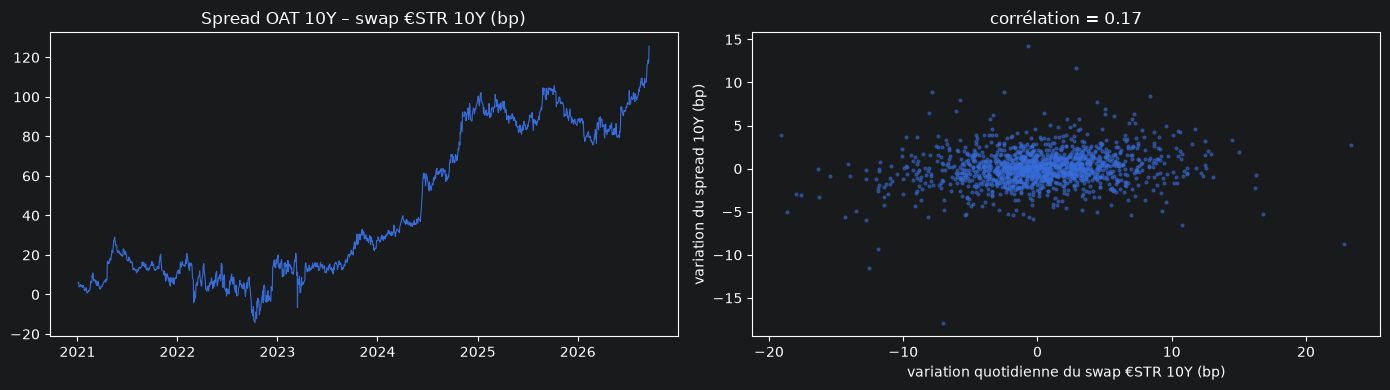

In [15]:
def ou_from_series(s, dt=1 / 252):
    """AR(1) sur le niveau -> a ; écart-type des variations -> vol annualisée."""
    s = s.dropna().values
    X = np.column_stack([np.ones(len(s) - 1), s[:-1]])
    c, phi = np.linalg.lstsq(X, s[1:], rcond=None)[0]
    return -np.log(phi) / dt, np.std(np.diff(s), ddof=1) / np.sqrt(dt)

def credit_estimates(hist_oat, hist_estr, start):
    rows = []
    for tau in hist_oat.columns:
        s = (hist_oat[tau] - hist_estr[tau]).loc[start:].dropna()
        r = hist_estr[tau].loc[s.index]
        a_y, vol_s = ou_from_series(s)
        rho = np.corrcoef(np.diff(r.values), np.diff(s.values))[0, 1]
        if a_y <= 0:                                            # phi >= 1 : pas de retour à la moyenne détectable
            a_y = np.nan
        s_y = vol_s * tau / H(a_y, 0, tau)
        rows.append({"tenor": tau, "spread moyen (bp)": s.mean() * 1e4, "a_y": a_y, "demi-vie (ans)": np.log(2) / a_y,
                     "vol spread (bp/an)": vol_s * 1e4, "sigma_y": s_y, "rho": rho, "n": len(s)})
    return pd.DataFrame(rows).set_index("tenor")

fenetres = {"2021-2026": "2021-01-01", "3 ans": "2023-09-10", "1 an": "2025-09-10"}
est = {nom: credit_estimates(hist_oat, hist_estr, start) for nom, start in fenetres.items()}
for nom, tab in est.items():
    print(f"\nfenêtre {nom} :")
    print(tab.round({"spread moyen (bp)": 1, "a_y": 3, "demi-vie (ans)": 2, "vol spread (bp/an)": 1, "sigma_y": 4, "rho": 3}).to_string())

# --- paramètres retenus : tenor 10 ans, fenêtre complète
sel = est["2021-2026"].loc[10]
A_Y, S_Y, RHO = sel["a_y"], sel["sigma_y"], sel["rho"]
p_cal = params(a_x=A_X, s_x=S_X, a_y=A_Y, s_y=S_Y, rho=RHO)
print(f"\nPARAMÈTRES RETENUS : a_x = {A_X:.4f}  sigma_x = {S_X:.4%}  |  a_y = {A_Y:.4f}  sigma_y = {S_Y:.4%}  rho = {RHO:.3f}")
print(f"ordres de grandeur de Russo (Exhibits 3-4, corporate US 2017) : a_y = 0.18 - 0.31, rho = -0.5 -> +0.8, "
      f"sigma_y^Russo = 0.097 - 0.14 soit une vol de spread L sigma_y^Russo = 3.9 % - 5.7 % à L = 40 %")
print(f"sensibilité de a_y au tenor et à la fenêtre : de {min(t['a_y'].min() for t in est.values()):.2f} à {max(t['a_y'].max() for t in est.values()):.2f} (NaN = non estimable)"
      f" ; sigma_y de {min(t['sigma_y'].min() for t in est.values()):.4f} à {max(t['sigma_y'].max() for t in est.values()):.4f}"
      f" ; vol du spread 10 ans de {min(t.loc[10, 'vol spread (bp/an)'] for t in est.values()):.1f} à {max(t.loc[10, 'vol spread (bp/an)'] for t in est.values()):.1f} bp/an")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
s10 = (hist_oat[10] - hist_estr[10]).dropna()
ax[0].plot(s10.index, s10 * 1e4, lw=0.8); ax[0].set_title("Spread OAT 10Y – swap €STR 10Y (bp)")
ax[1].scatter(np.diff(hist_estr[10].loc[s10.index].values) * 1e4, np.diff(s10.values) * 1e4, s=4, alpha=0.5)
ax[1].set_xlabel("variation quotidienne du swap €STR 10Y (bp)"); ax[1].set_ylabel("variation du spread 10Y (bp)"); ax[1].set_title(f"corrélation = {RHO:.2f}")
plt.tight_layout(); plt.show()

## 10. Validation par Monte-Carlo

La formule fermée repose sur une seule approximation : l'hypothèse lognormale à poids gelés pour
$\bar B(T_0)$. Le prix exact est $\mathbb E^{\mathbb Q}\big[e^{-\int_0^{T_0}r}\,(\bar B(T_0)-X)^+\big]$ et
tout ce qui y entre est fonction du vecteur gaussien

$$Z = \Big(x(T_0),\ y(T_0),\ I_x = \int_0^{T_0}x\,du,\ I_y = \int_0^{T_0}y\,du\Big),$$

de moyenne nulle sous $\mathbb Q$ et de matrice de covariance donnée par la section 4. On **simule $Z$
exactement** (Cholesky), sans discrétisation en temps :

- $e^{-\int_0^{T_0}r} = e^{-\int_0^{T_0}\alpha}\,e^{-I_x} = P^M(0,T_0)\,e^{-\frac12V_x(0,T_0)}\,e^{-I_x}$ ;
- $\bar B(T_0) = \sum_{T_i>T_0}K_i\,\bar P(T_0,T_i;\,x(T_0),y(T_0))$, formule fermée de la section 7 ;
- variables antithétiques et intervalle de confiance à 95 %.

Deux contrôles internes précèdent le pricing : $\mathbb E[e^{-\int r}] = P^M(0,T_0)$ et
$\mathbb E[e^{-\int\bar r}] = \bar P^M(0,T_0)$ (ce dernier teste $\bar V$ et toute la matrice de covariance),
puis $\mathbb E[e^{-\int r}\bar B(T_0)]/P(0,T_0) = M$ teste l'espérance forward de la section 8. L'écart
fermé / Monte-Carlo par strike mesure alors l'erreur des poids gelés, que Russo et al. trouvent inférieure
à 2 % avec 25 000 trajectoires.

In [16]:
"""
Monte-Carlo exact du vecteur gaussien (x(T0), y(T0), int x, int y)

"""
import numpy as np

class hw2f_mc:

    def __init__(self, m, T0, n_paths=200_000, seed=0):
        p, self.m, self.T0 = m.p, m, T0
        vx, vy = var_factor(p.a_x, p.s_x, 0, T0), var_factor(p.a_y, p.s_y, 0, T0)
        cxy = cov_xy(p, 0, T0)
        Vx, Vy, Vxy = V(p.a_x, p.s_x, 0, T0), V(p.a_y, p.s_y, 0, T0), V_xy(p, 0, T0) / 2
        c_x_Ix, c_y_Iy = cov_factor_int(p.a_x, p.s_x, 0, T0), cov_factor_int(p.a_y, p.s_y, 0, T0)
        c_y_Ix, c_x_Iy = cov_cross_int(p, 0, T0), cov_cross_int(swap_xy(p), 0, T0)
        self.cov = np.array([[vx,     cxy,    c_x_Ix, c_x_Iy],
                             [cxy,    vy,     c_y_Ix, c_y_Iy],
                             [c_x_Ix, c_y_Ix, Vx,     Vxy],
                             [c_x_Iy, c_y_Iy, Vxy,    Vy]])
        Lc = np.linalg.cholesky(self.cov)
        g = np.random.default_rng(seed).standard_normal((4, n_paths // 2))
        Z = Lc @ np.concatenate([g, -g], axis=1)                       # antithétiques
        self.x, self.y, self.Ix, self.Iy = Z
        self.disc = m.rf.curve.df(T0) * np.exp(-0.5 * V(p.a_x, p.s_x, 0, T0)) * np.exp(-self.Ix)          # e^{-int r} = e^{-int alpha} e^{-I_x}
        self.disc_bar = m.risky.df(T0) * np.exp(-0.5 * m.V_bar(0, T0)) * np.exp(-self.Ix - self.Iy)        # e^{-int r_bar}

    def bond(self, bd):
        bd = bd.after(self.T0)
        return np.sum(bd.K[:, None] * self.m.Pbar(self.T0, bd.T[:, None], self.x[None, :], self.y[None, :]), axis=0)

    def price(self, bd, X, call=True):
        B = self.bond(bd)
        pay = self.disc * (np.maximum(B - X, 0) if call else np.maximum(X - B, 0))
        pay = pay.reshape(2, -1).mean(axis=0)                            # moyenne des paires antithétiques
        return pay.mean(), 1.96 * pay.std(ddof=1) / np.sqrt(len(pay))

matrice de covariance de (x, y, int x, int y) : définie positive = True
E[e^-int r]     = 0.944736   P^M(0,2)    = 0.944736
E[e^-int r_bar] = 0.939528   Pbar^M(0,2) = 0.939528
E[e^-int r Bbar(T0)] / P(0,T0) = 97.3022   M (fermé) = 97.3020   (prix pour 100)
écart-type de log Bbar(T0) simulé = 0.08275   Sigma_B (poids gelés) = 0.08279

fermé vs Monte-Carlo  OAT 2036  T0 = 2 ans  400 000 trajectoires (prix pour 100) :
strike (% de M) type  fermé     MC  IC 95%  écart %
            90% call 9.5406 9.5326  0.0064     0.08
            90%  put 0.3481 0.3399  0.0039     2.41
            95% call 5.8076 5.8008  0.0097     0.12
            95%  put 1.2113 1.2044  0.0071     0.58
           100% call 3.0353 3.0369  0.0113    -0.05
           100%  put 3.0353 3.0367  0.0088    -0.05
           105% call 1.3378 1.3448  0.0090    -0.52
           105%  put 5.9340 5.9409  0.0064    -0.12
           110% call 0.4942 0.5024  0.0058    -1.62
           110%  put 9.6867 9.6947  0.0034    -0.08

erreur d

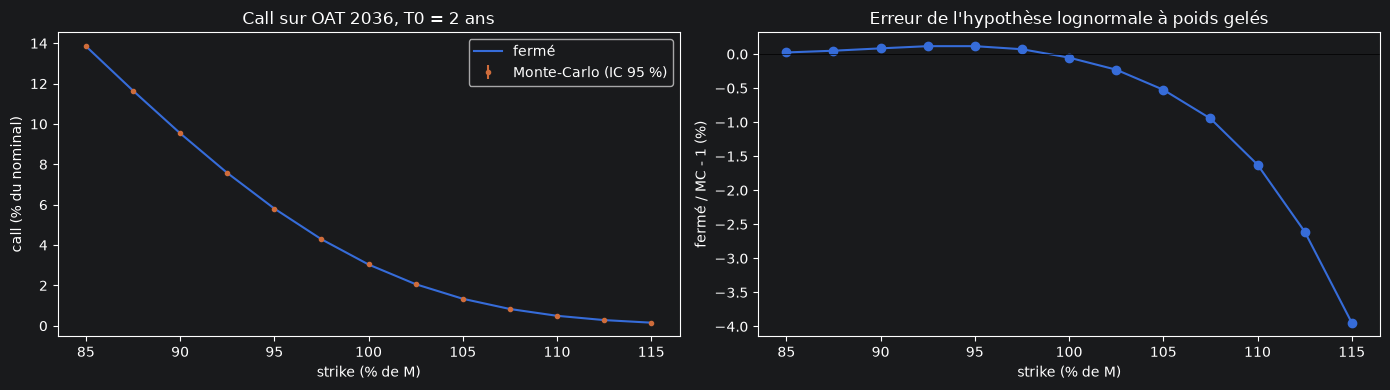

In [17]:
m_cal = hw2f_model(curve, risky, p_cal)
T0 = 2.0
mc = hw2f_mc(m_cal, T0, n_paths=400_000)
print("matrice de covariance de (x, y, int x, int y) : définie positive =", np.all(np.linalg.eigvalsh(mc.cov) > 0))
print(f"E[e^-int r]     = {mc.disc.mean():.6f}   P^M(0,{T0:.0f})    = {curve.df(T0):.6f}")
print(f"E[e^-int r_bar] = {mc.disc_bar.mean():.6f}   Pbar^M(0,{T0:.0f}) = {risky.df(T0):.6f}")
B = mc.bond(oat10)
M = m_cal.forward_M(0, T0, oat10)
print(f"E[e^-int r Bbar(T0)] / P(0,T0) = {np.mean(mc.disc * B) / curve.df(T0) * 100:.4f}   M (fermé) = {M * 100:.4f}   (prix pour 100)")
print(f"écart-type de log Bbar(T0) simulé = {np.std(np.log(B)):.5f}   Sigma_B (poids gelés) = {m_cal.sigma_B(0, T0, oat10):.5f}")

print(f"\nfermé vs Monte-Carlo, OAT 2036, T0 = {T0:.0f} ans, {len(mc.x):,} trajectoires (prix pour 100) :".replace(",", " "))
rows = []
for k in [0.90, 0.95, 1.00, 1.05, 1.10]:
    X = k * M
    for call in [True, False]:
        ferme = m_cal.option(0, T0, oat10, X, call=call) * 100
        mcp, ic = mc.price(oat10, X, call)
        rows.append({"strike (% de M)": f"{k:.0%}", "type": "call" if call else "put", "fermé": ferme, "MC": mcp * 100, "IC 95%": ic * 100, "écart %": (ferme / (mcp * 100) - 1) * 100})
print(pd.DataFrame(rows).round({"fermé": 4, "MC": 4, "IC 95%": 4, "écart %": 2}).to_string(index=False))

print("\nerreur des poids gelés selon l'expiry (call et put ATM-forward) :")
for T0 in [1.0, 2.0, 5.0]:
    mc_ = hw2f_mc(m_cal, T0, n_paths=400_000)
    M = m_cal.forward_M(0, T0, oat10)
    c_f, (c_mc, ic_c) = m_cal.option(0, T0, oat10, M) * 100, mc_.price(oat10, M)
    print(f"  T0 = {T0:.0f} : call fermé = {c_f:.4f}   MC = {c_mc * 100:.4f} ± {ic_c * 100:.4f}   écart = {(c_f / (c_mc * 100) - 1) * 100:+.2f} %")

ks = np.linspace(0.85, 1.15, 13)
T0 = 2.0; M = m_cal.forward_M(0, T0, oat10)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ferme = [m_cal.option(0, T0, oat10, k * M) * 100 for k in ks]
mcs = [mc.price(oat10, k * M) for k in ks]
ax[0].plot(ks * 100, ferme, label="fermé"); ax[0].errorbar(ks * 100, [v[0] * 100 for v in mcs], yerr=[v[1] * 100 for v in mcs], fmt=".", label="Monte-Carlo (IC 95 %)")
ax[0].set_xlabel("strike (% de M)"); ax[0].set_ylabel("call (% du nominal)"); ax[0].legend(); ax[0].set_title(f"Call sur OAT 2036, T0 = {T0:.0f} ans")
ax[1].plot(ks * 100, [(f / (v[0] * 100) - 1) * 100 for f, v in zip(ferme, mcs)], "o-"); ax[1].axhline(0, color="k", lw=0.5)
ax[1].set_xlabel("strike (% de M)"); ax[1].set_ylabel("fermé / MC - 1 (%)"); ax[1].set_title("Erreur de l'hypothèse lognormale à poids gelés")
plt.tight_layout(); plt.show()

## 11. Résultats

Sous-jacent : l'OAT 3,70 % 25/11/2036 (FR0014018YR0), benchmark 10 ans. Options d'expiry 1, 2 et 5 ans,
strikes de 90 % à 110 % du forward $M$. On compare :

- le **modèle à deux facteurs** calibré (section 9) ;
- le **facteur taux seul** ($\sigma_y = 0$, spread déterministe) : la même OAT, la même courbe, mais sans
  volatilité de spread. C'est ce qu'un pricer Hull-White à un facteur sur la courbe OAT donnerait ;
- le **Monte-Carlo** exact comme référence.

Puis les sensibilités aux paramètres crédit. La grille en $L$ de l'Exhibit 7 de Russo (à $\sigma_y^{R}$ fixé)
est une grille en volatilité de spread : on la reproduit avec $\sigma_y \in \{0{,}5, 1, 2, 5, 10\} \times$ la
valeur historique, la dernière valeur (4 % par an) étant l'ordre de grandeur des vols de spread de Russo.
Puis $\rho$ et $a_y$.

In [18]:
m_1f = hw2f_model(curve, risky, replace(p_cal, s_y=1e-12))
print(f"OAT 2036 : prix dirty = {m_cal.bond_price(0, oat10, 0, 0) * 100:.3f}   D_x = {m_cal.durations(0, oat10, 0, 0)[0]:.3f}   D_y = {m_cal.durations(0, oat10, 0, 0)[1]:.3f}\n")
rows = []
for T0 in [1.0, 2.0, 5.0]:
    M = m_cal.forward_M(0, T0, oat10)
    mc_ = hw2f_mc(m_cal, T0, n_paths=400_000, seed=1)
    parts = m_cal.sigma_B2_parts(0, T0, oat10)
    for k in [0.90, 0.95, 1.00, 1.05, 1.10]:
        X = k * M
        c_mc, ic = mc_.price(oat10, X)
        rows.append({"T0": T0, "M": M * 100, "strike %M": f"{k:.0%}", "call 2F": m_cal.option(0, T0, oat10, X) * 100, "put 2F": m_cal.option(0, T0, oat10, X, call=False) * 100,
                     "call 1F": m_1f.option(0, T0, oat10, X) * 100, "put 1F": m_1f.option(0, T0, oat10, X, call=False) * 100,
                     "call MC": c_mc * 100, "±": ic * 100, "Sigma_B 2F": np.sqrt(sum(parts)), "Sigma_B 1F": np.sqrt(parts[0])})
res = pd.DataFrame(rows)
print("prix en % du nominal (strike sur le prix dirty, en % du forward M) :")
print(res.round({"M": 3, "call 2F": 4, "put 2F": 4, "call 1F": 4, "put 1F": 4, "call MC": 4, "±": 4, "Sigma_B 2F": 4, "Sigma_B 1F": 4}).to_string(index=False))

print("\ndécomposition de la variance Sigma_B^2 (poids gelés) :")
for T0 in [1.0, 2.0, 5.0]:
    parts = m_cal.sigma_B2_parts(0, T0, oat10); tot = sum(parts)
    print(f"  T0 = {T0:.0f} : taux {parts[0] / tot:6.1%}   crédit {parts[1] / tot:6.1%}   croisé {parts[2] / tot:+6.1%}   Sigma_B = {np.sqrt(tot):.4f}")

OAT 2036 : prix dirty = 98.690   D_x = 7.837   D_y = 6.673

prix en % du nominal (strike sur le prix dirty, en % du forward M) :
 T0      M strike %M  call 2F  put 2F  call 1F  put 1F  call MC      ±  Sigma_B 2F  Sigma_B 1F
1.0 97.829       90%   9.6456  0.1258   9.5810  0.0545   9.6404 0.0035      0.0646      0.0553
1.0 97.829       95%   5.4875  0.7276   5.2562  0.4897   5.4774 0.0067      0.0646      0.0553
1.0 97.829      100%   2.4525  2.4525   2.1051  2.0984   2.4455 0.0088      0.0646      0.0553
1.0 97.829      105%   0.8185  5.5783   0.5620  5.3152   0.8201 0.0063      0.0646      0.0553
1.0 97.829      110%   0.1996  9.7194   0.0960  9.6091   0.2042 0.0032      0.0646      0.0553
2.0 97.302       90%   9.5406  0.3481   9.4019  0.1866   9.5297 0.0064      0.0828      0.0710
2.0 97.302       95%   5.8076  1.2113   5.4883  0.8692   5.7931 0.0097      0.0828      0.0710
2.0 97.302      100%   3.0353  3.0353   2.6147  2.5919   3.0264 0.0113      0.0828      0.0710
2.0 97.302      

sensibilité à sigma_y (T0 = 2 ans, strikes en % de M du cas central, prix en % du nominal) :
 sigma_y  x hist.       M  Sigma_B  part crédit  call 100%  put 100%  call 95%  put 105%
  0.0021      0.5 97.3185   0.0754        0.046     2.7723    2.7567    5.6055    5.6931
  0.0042      1.0 97.3020   0.0828        0.153     3.0353    3.0353    5.8076    5.9340
  0.0083      2.0 97.2426   0.1038        0.390     3.7754    3.8315    6.4113    6.6576
  0.0208      5.0 96.8534   0.1875        0.748     6.6393    7.0631    8.9689    9.8129
  0.0416     10.0 95.5137   0.3433        0.892    11.5849   13.2743   13.6063   16.1093

sensibilité à rho et a_y (T0 = 2 ans, call ATM-forward à X = M du cas central) :
paramètre  valeur       M  Sigma_B  part croisée   call    put
      rho   -0.60 97.3320   0.0577        -0.830 2.1303 2.1020
      rho   -0.30 97.3203   0.0686        -0.293 2.5253 2.5081
      rho    0.00 97.3085   0.0780         0.000 2.8647 2.8585
      rho    0.30 97.2968   0.0864     

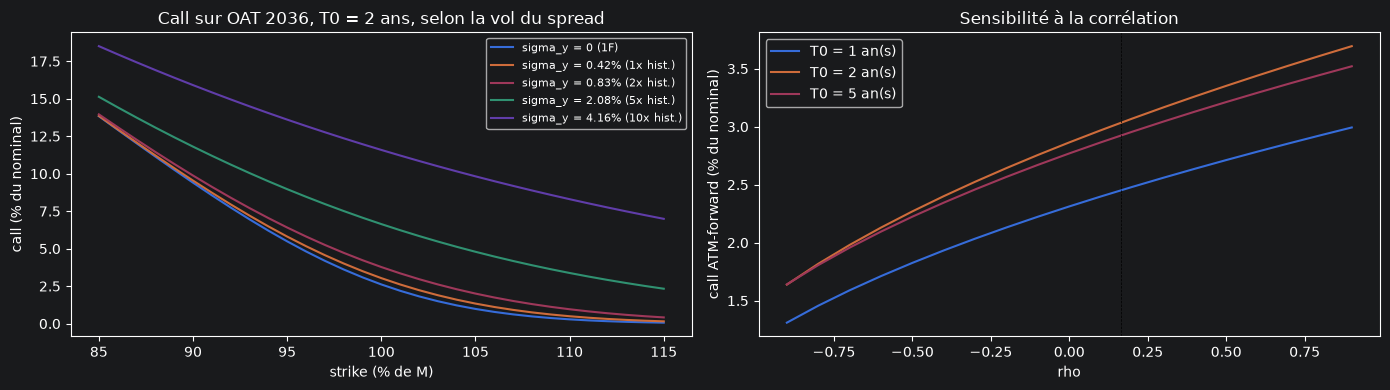

In [19]:
T0 = 2.0
M = m_cal.forward_M(0, T0, oat10)

# --- 1. volatilité du spread (équivalent de la grille en L de l'Exhibit 7 de Russo)
print(f"sensibilité à sigma_y (T0 = {T0:.0f} ans, strikes en % de M du cas central, prix en % du nominal) :")
rows = []
for k in [0.5, 1, 2, 5, 10]:
    mk = hw2f_model(curve, risky, replace(p_cal, s_y=p_cal.s_y * k))
    parts = mk.sigma_B2_parts(0, T0, oat10)
    rows.append({"sigma_y": p_cal.s_y * k, "x hist.": k, "M": mk.forward_M(0, T0, oat10) * 100, "Sigma_B": np.sqrt(sum(parts)), "part crédit": parts[1] / sum(parts),
                 "call 100%": mk.option(0, T0, oat10, M) * 100, "put 100%": mk.option(0, T0, oat10, M, call=False) * 100,
                 "call 95%": mk.option(0, T0, oat10, 0.95 * M) * 100, "put 105%": mk.option(0, T0, oat10, 1.05 * M, call=False) * 100})
print(pd.DataFrame(rows).round({"sigma_y": 4, "M": 4, "Sigma_B": 4, "part crédit": 3, "call 100%": 4, "put 100%": 4, "call 95%": 4, "put 105%": 4}).to_string(index=False))

# --- 2. rho, a_y
print(f"\nsensibilité à rho et a_y (T0 = {T0:.0f} ans, call ATM-forward à X = M du cas central) :")
rows = []
for nom, kw in [("rho", {"rho": r}) for r in [-0.6, -0.3, 0.0, 0.3, 0.6]] + [("a_y", {"a_y": a}) for a in [0.05, 0.25, 0.5, 1.0]]:
    mk = hw2f_model(curve, risky, replace(p_cal, **kw))
    parts = mk.sigma_B2_parts(0, T0, oat10)
    rows.append({"paramètre": nom, "valeur": list(kw.values())[0], "M": mk.forward_M(0, T0, oat10) * 100, "Sigma_B": np.sqrt(sum(parts)), "part croisée": parts[2] / sum(parts),
                 "call": mk.option(0, T0, oat10, M) * 100, "put": mk.option(0, T0, oat10, M, call=False) * 100})
print(pd.DataFrame(rows).round({"valeur": 4, "M": 4, "Sigma_B": 4, "part croisée": 3, "call": 4, "put": 4}).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ks = np.linspace(0.85, 1.15, 31)
for k in [0, 1, 2, 5, 10]:
    mk = hw2f_model(curve, risky, replace(p_cal, s_y=p_cal.s_y * k)) if k > 0 else m_1f
    ax[0].plot(ks * 100, [mk.option(0, T0, oat10, kk * M) * 100 for kk in ks], label=f"sigma_y = {p_cal.s_y * k:.2%} ({k}x hist.)" if k > 0 else "sigma_y = 0 (1F)")
ax[0].set_xlabel("strike (% de M)"); ax[0].set_ylabel("call (% du nominal)"); ax[0].legend(fontsize=8); ax[0].set_title(f"Call sur OAT 2036, T0 = {T0:.0f} ans, selon la vol du spread")
rhos = np.linspace(-0.9, 0.9, 19)
for T0_ in [1.0, 2.0, 5.0]:
    M_ = m_cal.forward_M(0, T0_, oat10)
    ax[1].plot(rhos, [hw2f_model(curve, risky, replace(p_cal, rho=r)).option(0, T0_, oat10, M_) * 100 for r in rhos], label=f"T0 = {T0_:.0f} an(s)")
ax[1].axvline(p_cal.rho, color="k", lw=0.5, ls="--"); ax[1].set_xlabel("rho"); ax[1].set_ylabel("call ATM-forward (% du nominal)"); ax[1].legend(); ax[1].set_title("Sensibilité à la corrélation")
plt.tight_layout(); plt.show()

### Lecture des résultats

- **Effet du facteur crédit.** Avec les paramètres historiques, la composante crédit apporte environ 15 %
  de la variance du prix forward de l'OAT et le terme croisé 11 % de plus ($\rho > 0$ sur 2021-2026 : le
  spread s'élargit quand les taux montent). La volatilité totale $\bar\Sigma_B$ dépasse de 17 % celle du
  facteur taux seul, et les options à la monnaie sont plus chères de 15 à 20 %. Sur les puts hors de la
  monnaie, où seule la queue basse du prix compte, l'écart relatif est bien plus grand.
- **Forward.** $M$ est inférieur de quelques centimes au forward de survie $\bar B/\bar P$ : convexité
  propre du spread, renforcée par la corrélation positive (le tableau de sensibilité montre $M$ décroissant
  en $\rho$, et $M > \bar B/\bar P$ seulement pour $\rho$ franchement négatif). Le forward reste dominé par
  la courbe, pas par la dynamique.
- **Monte-Carlo.** L'hypothèse lognormale à poids gelés coûte moins de 0,1 % à la monnaie et de l'ordre de
  1 à 2 % très en dehors de la monnaie, en dessous du seuil de 2 % rapporté par Russo et al.
- **$\sigma_y$.** Le prix croît avec la volatilité du spread, comme dans l'Exhibit 7 de Russo. Avec des
  vols de spread de l'ordre de celles de Russo (4 % par an), la composante crédit dominerait la composante
  taux ; sur les OAT, elle reste secondaire.
- **$\rho$ et $a_y$.** La corrélation est le paramètre crédit le plus sensible, via le terme croisé de
  $\bar\Sigma_B^2$ (de $-0{,}6$ à $+0{,}6$, le call à la monnaie varie de plus ou moins 30 %). Une vitesse
  de retour $a_y$ plus élevée réduit la duration crédit $D_y$ et donc l'effet du spread, à $\sigma_y$ fixé.

## 12. Conclusion et limites

**Ce qui a été fait.** Le modèle à deux facteurs de Russo, Giacometti et Fabozzi a été reconstruit brique
par brique sur des données françaises : courbe €STR bootstrappée, courbe OAT ajustée par
Nelson-Siegel-Svensson, facteur taux calibré sur la diagonale co-terminale des swaptions ATM, facteur crédit
estimé sur l'historique du spread OAT–€STR. La formule fermée pour l'option **sans knock-out** a été dérivée
par changement de numéraire vers le zéro-coupon sans risque : elle ne diffère de celle de Russo que par le
numéraire et par le forward $M$, qui est l'espérance sous la mesure forward sans risque du prix risqué et
qui contient un terme de covariance taux/spread. Chaque brique a été vérifiée (recalage exact des courbes,
dérivées, quadratures, parités, cas limites), le pricer 1F a été contrôlé par Jamshidian, et le pricer 2F par
un Monte-Carlo exact sans discrétisation qui isole l'erreur de l'unique approximation du modèle, l'hypothèse
lognormale à poids gelés.

**Ce que disent les résultats.** La volatilité du spread OAT est faible devant celle des taux : la
composante crédit modifie les prix d'options de quelques pour cent au plus, avec un effet de la corrélation
qui passe par le terme croisé de $\bar\Sigma_B^2$ et par le forward $M$. L'erreur des poids gelés reste bien
en dessous des 2 % annoncés par Russo sur les strikes usuels. La procédure de calibration de l'étape 2 de
Russo (ajustement de la courbe risquée) ne peut pas identifier $(a_y,\sigma_y,\rho)$ parce que la courbe est
recalée par construction : elle ne mesure que la convexité du modèle. La calibration historique est une
réponse pragmatique, avec ses limites.

**Limites.**

1. *Poids gelés* : l'hypothèse lognormale est une approximation, contrôlée ici par Monte-Carlo pour des
   options jusqu'à 5 ans sur une obligation 10 ans ; l'erreur croît avec l'expiry et la dispersion des
   flux.
2. *Spread gaussien* : le spread peut devenir négatif, ce qui est acceptable pour un souverain dont le
   spread contient des primes de liquidité et de collatéral, mais il n'est pas une intensité de défaut
   pure et le modèle ne fournit pas de probabilité de défaut sans retraitement.
3. *Pas de séparation intensité / recouvrement* : le modèle est écrit sur le spread ; la perte en cas de
   défaut $L$ de Russo n'est pas un paramètre du pricer et n'a pas été introduite. Elle ne le deviendrait
   que pour une option dont le règlement dépend du recouvrement.

4. *Calibration sous la mesure historique* : $a_y$ et $\rho$ sont estimés sous $\mathbb P$ ; la vitesse de
   retour risque-neutre peut différer, et l'estimation de $a_y$ sur cinq ans de données est imprécise.
   Seule la volatilité est invariante par changement de mesure.
5. *Conventions simplifiées* : pas de calendrier, ACT/365, jambe fixe annuelle, vols de swaptions
   supposées cohérentes avec l'actualisation €STR.
6. *Pas de knock-out et pas de protection au défaut* : l'option est traitée comme un contrat collatéralisé
   dont le règlement ne dépend que du prix de marché de l'OAT à l'échéance ; la version knock-out de
   Russo et la version « protégée » de Schönbucher (exercice immédiat au défaut) ne sont pas traitées.

**Perspectives.** Volatilité $\sigma_x(t)$ constante par morceaux calibrée par bootstrap sur la diagonale ;
comparaison avec les volatilités implicites des options sur future OAT (Euronext), qui mêlent option de
livraison et CTD ; calibration du facteur crédit sur les CDS France si un modèle de spread CDS cohérent est
adjoint.